# Metabolomics DSP Course - Data Analysis

### Data setup

In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [363]:
#metaboigniter_data = pd.read_csv("../../dataset_metaboigniter_output/output_quantification_Linked_data.tsv", sep="\t")

metaboigniter_data = pd.read_csv("/Users/fcasc/Documents/Courses/DSP_MetabolomicsCourse/dataset_metaboigniter_output/Metabonaut_intensities_xcms.csv", index_col=0)
metaboigniter_metadata = pd.read_csv("/Users/fcasc/Documents/Courses/DSP_MetabolomicsCourse/dataset_metaboigniter_output/Metabonaut_peaks_xcms.csv", index_col=0)



In [364]:
metaboigniter_data

,MS_QC_POOL_1_POS.mzML,MS_A_POS.mzML,MS_B_POS.mzML,MS_QC_POOL_2_POS.mzML,MS_C_POS.mzML,MS_D_POS.mzML,MS_QC_POOL_3_POS.mzML,MS_E_POS.mzML,MS_F_POS.mzML,MS_QC_POOL_4_POS.mzML
FT0001,421.616,689.242,411.344,481.744,314.768,635.273,439.609,570.585,579.936,437.034
FT0002,710.808,875.919,457.606,693.700,781.242,648.434,700.972,"1,054.021",534.458,711.036
FT0003,445.571,613.441,277.506,497.887,425.383,634.937,449.093,556.262,461.047,232.108
FT0004,"16,994.526","24,605.734","19,766.707","17,808.093","22,780.668","22,873.106","16,965.776","23,432.125","22,198.461","16,796.450"
FT0005,"3,284.266","4,526.053","3,521.822","3,379.891","4,396.076","4,317.773","3,270.529","4,533.867","4,161.013","3,142.227"
...,...,...,...,...,...,...,...,...,...,...
FT9064,490.878,14.264,NaN,893.118,3.608,NaN,929.286,NaN,NaN,"1,106.346"
FT9065,245.381,442.417,350.842,282.775,431.588,392.645,218.925,282.484,404.266,312.980
FT9066,232.739,271.101,230.013,241.505,280.714,297.172,231.721,212.003,164.105,242.896
FT9067,192.344,212.819,216.832,197.947,252.792,233.470,134.870,203.199,140.563,195.060


In [365]:
metaboigniter_data.columns

Index(['MS_QC_POOL_1_POS.mzML', 'MS_A_POS.mzML', 'MS_B_POS.mzML',
       'MS_QC_POOL_2_POS.mzML', 'MS_C_POS.mzML', 'MS_D_POS.mzML',
       'MS_QC_POOL_3_POS.mzML', 'MS_E_POS.mzML', 'MS_F_POS.mzML',
       'MS_QC_POOL_4_POS.mzML'],
      dtype='object')

Transpose data, remove metadata, make colnames nicer, reset imputation (everything below 1 becomes 0)

In [366]:
data = metaboigniter_data.T
#data = data.drop(['id', 'charge', 'RT', 'mz', 'quality', 'adduct', 'feature_ids'])
#data.columns = [f"F{i}" for i in range(len(data.columns))]
#data[data < 1] = float('nan')

In [367]:
data

,FT0001,FT0002,FT0003,FT0004,FT0005,FT0006,FT0007,FT0008,FT0009,FT0010,...,FT9059,FT9060,FT9061,FT9062,FT9063,FT9064,FT9065,FT9066,FT9067,FT9068
MS_QC_POOL_1_POS.mzML,421.616,710.808,445.571,"16,994.526","3,284.266","10,681.748","14,704.174","80,134.729","26,622.615","22,798.051",...,496.728,295.384,247.175,420.181,761.531,490.878,245.381,232.739,192.344,153.760
MS_A_POS.mzML,689.242,875.919,613.441,"24,605.734","4,526.053","10,009.660","30,478.773","61,596.178","34,580.423","18,796.818",...,402.826,230.788,348.719,404.311,731.315,14.264,442.417,271.101,212.819,287.617
MS_B_POS.mzML,411.344,457.606,277.506,"19,766.707","3,521.822","9,599.970","50,639.168","75,630.375","43,616.378","22,978.895",...,281.401,139.503,261.502,466.625,646.562,NaN,350.842,230.013,216.832,257.390
MS_QC_POOL_2_POS.mzML,481.744,693.700,497.887,"17,808.093","3,379.891","10,800.545","33,109.022","69,417.441","19,273.719","7,962.153",...,279.896,413.087,171.507,413.937,817.964,893.118,282.775,241.505,197.947,260.148
MS_C_POS.mzML,314.768,781.242,425.383,"22,780.668","4,396.076","4,792.239","69,766.107","16,257.662","36,992.337","23,687.377",...,552.032,327.069,336.601,520.378,528.355,3.608,431.588,280.714,252.792,376.961
MS_D_POS.mzML,635.273,648.434,634.937,"22,873.106","4,317.773","7,296.426","27,758.566","35,759.602","49,199.902","16,504.770",...,351.687,288.522,320.417,690.729,771.958,NaN,392.645,297.172,233.470,344.542
MS_QC_POOL_3_POS.mzML,439.609,700.972,449.093,"16,965.776","3,270.529","2,382.179","15,110.321","54,151.117","24,470.060","44,570.496",...,446.480,216.743,159.461,452.707,848.135,929.286,218.925,231.721,134.870,57.602
MS_E_POS.mzML,570.585,"1,054.021",556.262,"23,432.125","4,533.867","9,236.980","18,427.422","84,101.427","40,346.888","24,991.643",...,384.537,241.777,327.741,346.731,684.767,NaN,282.484,212.003,203.199,287.614
MS_F_POS.mzML,579.936,534.458,461.047,"22,198.461","4,161.013","6,817.878","15,789.176","14,200.817","39,119.993","22,190.860",...,412.916,239.366,84.827,562.770,21.967,NaN,404.266,164.105,140.563,364.157
MS_QC_POOL_4_POS.mzML,437.034,711.036,232.108,"16,796.450","3,142.227","6,911.544","41,577.764","25,577.307","26,245.174","3,242.386",...,376.843,200.077,256.747,452.970,887.850,"1,106.346",312.980,242.896,195.060,175.849


In [368]:
data.index

Index(['MS_QC_POOL_1_POS.mzML', 'MS_A_POS.mzML', 'MS_B_POS.mzML',
       'MS_QC_POOL_2_POS.mzML', 'MS_C_POS.mzML', 'MS_D_POS.mzML',
       'MS_QC_POOL_3_POS.mzML', 'MS_E_POS.mzML', 'MS_F_POS.mzML',
       'MS_QC_POOL_4_POS.mzML'],
      dtype='object')

In [369]:
samples = ['MS_F_POS.mzML', 'MS_E_POS.mzML', 
       'MS_C_POS.mzML', 'MS_A_POS.mzML',  
       'MS_B_POS.mzML', 'MS_D_POS.mzML']
samples_cvd = ['MS_F_POS.mzML', 
                'MS_A_POS.mzML',
                'MS_D_POS.mzML']
samples_ctr = ['MS_E_POS.mzML', 
                'MS_C_POS.mzML',
                'MS_B_POS.mzML']
qcs = ['MS_QC_POOL_1_POS.mzML', 'MS_QC_POOL_2_POS.mzML', 'MS_QC_POOL_3_POS.mzML', 'MS_QC_POOL_4_POS.mzML']

### Data filtering

In [370]:
from acore import filter_metabolomics as fm

80% rule for filtering

In [371]:
data_filtered_1 = fm.filter_by_missingness(
    data=data,
    method="modified",
    percent=50, # 80% present, 20% missing is allowed at most 
    groups={"samples_cvd": samples_cvd, "samples_ctr": samples_ctr} #don't filter qcs here yet
)

In [372]:
print(
    f"Num. of features before filtering: {data.shape[1]}\n"
    f"Num. of features after filtering: {data_filtered_1.shape[1]}"
)
print(
    f"Difference: {data.shape[1]-data_filtered_1.shape[1]} features removed."
)

Num. of features before filtering: 9068
Num. of features after filtering: 8724
Difference: 344 features removed.


!!!  Check missingness before !!!

CV-based filtering

In [373]:
data_filtered_2 = fm.filter_cv(
    data=data_filtered_1,
    samples=samples,
    qcs=qcs
)

CV is undefined for 171 feature(s) in QC samples (zero or near-zero mean): ['FT0166', 'FT0263', 'FT0497', 'FT0540', 'FT0557', 'FT0572', 'FT0581', 'FT0583', 'FT0669', 'FT0725', 'FT0752', 'FT0814', 'FT0816', 'FT1103', 'FT1167', 'FT1174', 'FT1223', 'FT1242', 'FT1254', 'FT1378', 'FT1451', 'FT1519', 'FT1538', 'FT1627', 'FT1642', 'FT1696', 'FT1805', 'FT1865', 'FT1956', 'FT1962', 'FT1976', 'FT2010', 'FT2018', 'FT2042', 'FT2414', 'FT2515', 'FT2557', 'FT2648', 'FT2728', 'FT2793', 'FT2808', 'FT2926', 'FT2932', 'FT3154', 'FT3263', 'FT3269', 'FT3289', 'FT3295', 'FT3297', 'FT3410', 'FT3419', 'FT3469', 'FT3511', 'FT3512', 'FT3515', 'FT3629', 'FT3680', 'FT3729', 'FT3852', 'FT4018', 'FT4095', 'FT4124', 'FT4131', 'FT4170', 'FT4215', 'FT4264', 'FT4283', 'FT4402', 'FT4429', 'FT4448', 'FT4469', 'FT4470', 'FT4490', 'FT4542', 'FT4568', 'FT4585', 'FT4586', 'FT4611', 'FT4627', 'FT4628', 'FT4641', 'FT4775', 'FT4792', 'FT4816', 'FT4829', 'FT4844', 'FT4905', 'FT4918', 'FT4961', 'FT4970', 'FT4981', 'FT4990', 'FT4

In [374]:
print(
    f"Num. of features before filtering: {data_filtered_1.shape[1]}\n"
    f"Num. of features after filtering: {data_filtered_2.shape[1]}"
)
print(
    f"Difference: {data_filtered_1.shape[1]-data_filtered_2.shape[1]} features removed."
)

Num. of features before filtering: 8724
Num. of features after filtering: 6658
Difference: 2066 features removed.


Blanks-based filtering: not possible (no blanks)

### Imputation

In [375]:
from acore.imputation_analysis import (
    imputation_half_minimum,
    imputation_zeros,
)

In [376]:

def plot_feature_missingness(data):
    missing_features = data.isnull().mean() * 100
    missing_features_nonzero = missing_features[missing_features > 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    ax = axes[0]
    ax.hist(
        missing_features_nonzero.values,
        bins=30,
        color="mediumvioletred",
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Number of features")
    ax.set_title(
        f"Distribution of missingness\n({len(missing_features_nonzero)} features with any missing)"
    )
    ax.axvline(
        x=20, color="black", linestyle="--", linewidth=0.8, label="20% threshold"
    )
    ax.legend()

    # Dot plot, sorted by missingness
    ax = axes[1]
    sorted_missing = missing_features.sort_values(ascending=True).reset_index(drop=True)
    ax.scatter(
        sorted_missing.index,
        sorted_missing.values,
        s=4,
        color="mediumvioletred",
        alpha=0.6,
        linewidths=0,
    )
    ax.set_xlabel("Features (sorted by missingness)")
    ax.set_ylabel("Missing (%)")
    ax.set_title("Sorted missingness per feature")
    ax.axhline(
        y=20, color="black", linestyle="--", linewidth=0.8, label="20% threshold"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()


def missingness_summary(df_before, df_after):
    total = df_before.size
    n_before = df_before.isnull().sum().sum()
    n_after = df_after.isnull().sum().sum()

    print(f"Total values      : {total:,}")
    print(f"Missing before    : {n_before:,}  ({100*n_before/total:.1f}%)")
    print(f"Missing after     : {n_after:,}  ({100*n_after/total:.1f}%)")
    print(
        f"Features affected : {(df_before.isnull().any()).sum()} / {df_before.shape[1]}"
    )
    print(
        f"Samples affected  : {(df_before.isnull().any(axis=1)).sum()} / {df_before.shape[0]}"
    )


def plot_intensity_distribution(data):
    values = data.values.flatten().astype(float)

    n_total = data.size
    n_missing = int(np.isnan(values).sum())
    pct_missing = n_missing / n_total * 100

    log_values = np.log10(values[(~np.isnan(values)) & (values > 0)])

    fig, (ax_nan, ax_hist) = plt.subplots(
        1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 8]}, sharey=True
    )

    ax_nan.bar(0, n_missing, width=0.2, color="mediumvioletred", alpha=0.8)
    ax_nan.set_xlim(-0.5, 0.5)
    ax_nan.set_xticks([0])
    ax_nan.set_xticklabels([f"NaN\n({pct_missing:.1f}%)"], fontsize=9)
    ax_nan.set_ylabel("Count")

    ax_hist.hist(
        log_values, bins=100, color="cornflowerblue", edgecolor="none", alpha=0.8
    )
    ax_hist.set_xlabel("Intensity (log₁₀)")
    ax_hist.set_title("Intensity distribution (all features, all samples)")
    ax_hist.yaxis.set_visible(False)

    plt.tight_layout()
    plt.show()

Total count of missing cells: 1893
Overall percentage of missingness: 2.843196155001502



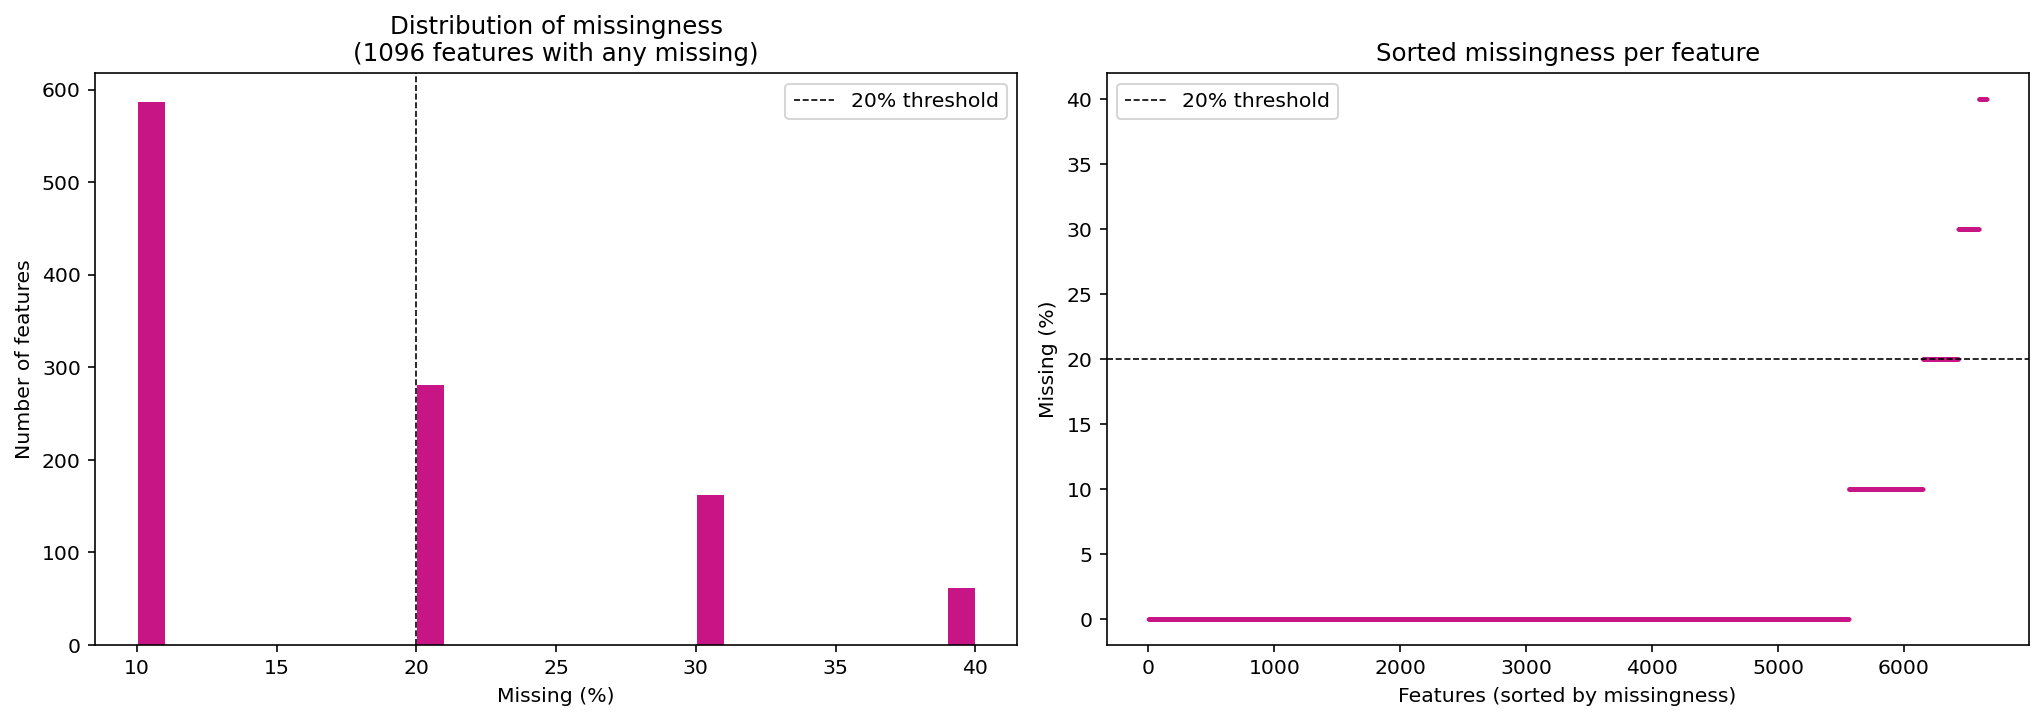

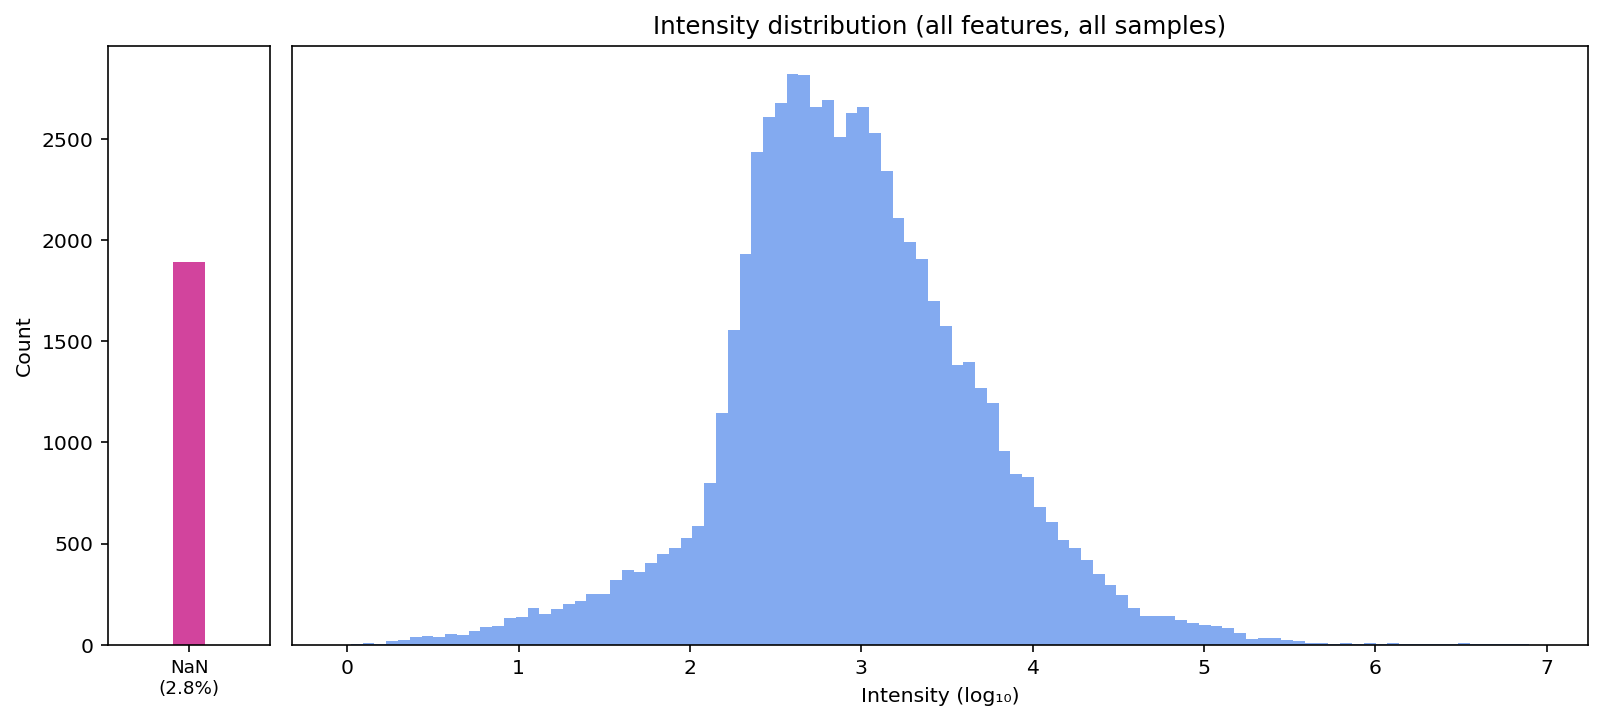

In [377]:
# Total missing count and percentage
print(
    f"Total count of missing cells: {data_filtered_2.isnull().sum().sum()}"
)  # total missing cells
print(
    f"Overall percentage of missingness: {data_filtered_2.isnull().mean().mean() * 100}\n"
)  # overall % missing

plot_feature_missingness(data_filtered_2)
plot_intensity_distribution(data_filtered_2)

Impute with half minimum

In [378]:
data_imputed = imputation_half_minimum(data=data_filtered_2)

In [379]:
data_imputed

,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,FT0014,FT0015,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
MS_QC_POOL_1_POS.mzML,421.616,710.808,"16,994.526","3,284.266","14,704.174","80,134.729",195.523,405.529,818.411,260.218,...,121.892,"1,185.436",406.282,175.735,201.255,247.175,420.181,761.531,232.739,192.344
MS_A_POS.mzML,689.242,875.919,"24,605.734","4,526.053","30,478.773","61,596.178",146.787,425.756,343.837,363.466,...,161.007,"1,017.731",532.110,225.729,393.021,348.719,404.311,731.315,271.101,212.819
MS_B_POS.mzML,411.344,457.606,"19,766.707","3,521.822","50,639.168","75,630.375",405.884,355.810,728.984,36.107,...,56.400,"1,075.977",431.187,129.292,303.388,261.502,466.625,646.562,230.013,216.832
MS_QC_POOL_2_POS.mzML,481.744,693.700,"17,808.093","3,379.891","33,109.022","69,417.441",133.342,414.845,487.844,231.858,...,217.061,"1,192.136",484.909,210.755,308.694,171.507,413.937,817.964,241.505,197.947
MS_C_POS.mzML,314.768,781.242,"22,780.668","4,396.076","69,766.107","16,257.662",285.928,487.997,396.557,64.465,...,233.339,911.474,323.251,124.374,388.791,336.601,520.378,528.355,280.714,252.792
MS_D_POS.mzML,635.273,648.434,"22,873.106","4,317.773","27,758.566","35,759.602",227.372,410.029,193.320,468.665,...,340.189,"1,130.625",602.739,209.080,370.025,320.417,690.729,771.958,297.172,233.470
MS_QC_POOL_3_POS.mzML,439.609,700.972,"16,965.776","3,270.529","15,110.321","54,151.117",174.984,376.485,698.329,222.050,...,160.504,"1,140.225",512.184,149.434,235.044,159.461,452.707,848.135,231.721,134.870
MS_E_POS.mzML,570.585,"1,054.021","23,432.125","4,533.867","18,427.422","84,101.427",275.206,521.332,533.046,499.954,...,168.651,"1,098.821",536.609,112.745,301.158,327.741,346.731,684.767,212.003,203.199
MS_F_POS.mzML,579.936,534.458,"22,198.461","4,161.013","15,789.176","14,200.817",185.370,280.465,202.432,3.146,...,297.407,201.144,457.226,155.108,54.589,84.827,562.770,21.967,164.105,140.563
MS_QC_POOL_4_POS.mzML,437.034,711.036,"16,796.450","3,142.227","41,577.764","25,577.307",154.214,453.282,665.090,264.590,...,243.218,"1,179.835",531.964,98.993,266.852,256.747,452.970,887.850,242.896,195.060


Total count of missing cells: 0
Overall percentage of missingness: 0.0

SUMMARY of imputation changes:
Total values      : 90,680
Missing before    : 4,675  (5.2%)
Missing after     : 0  (0.0%)
Features affected : 1902 / 9068
Samples affected  : 10 / 10


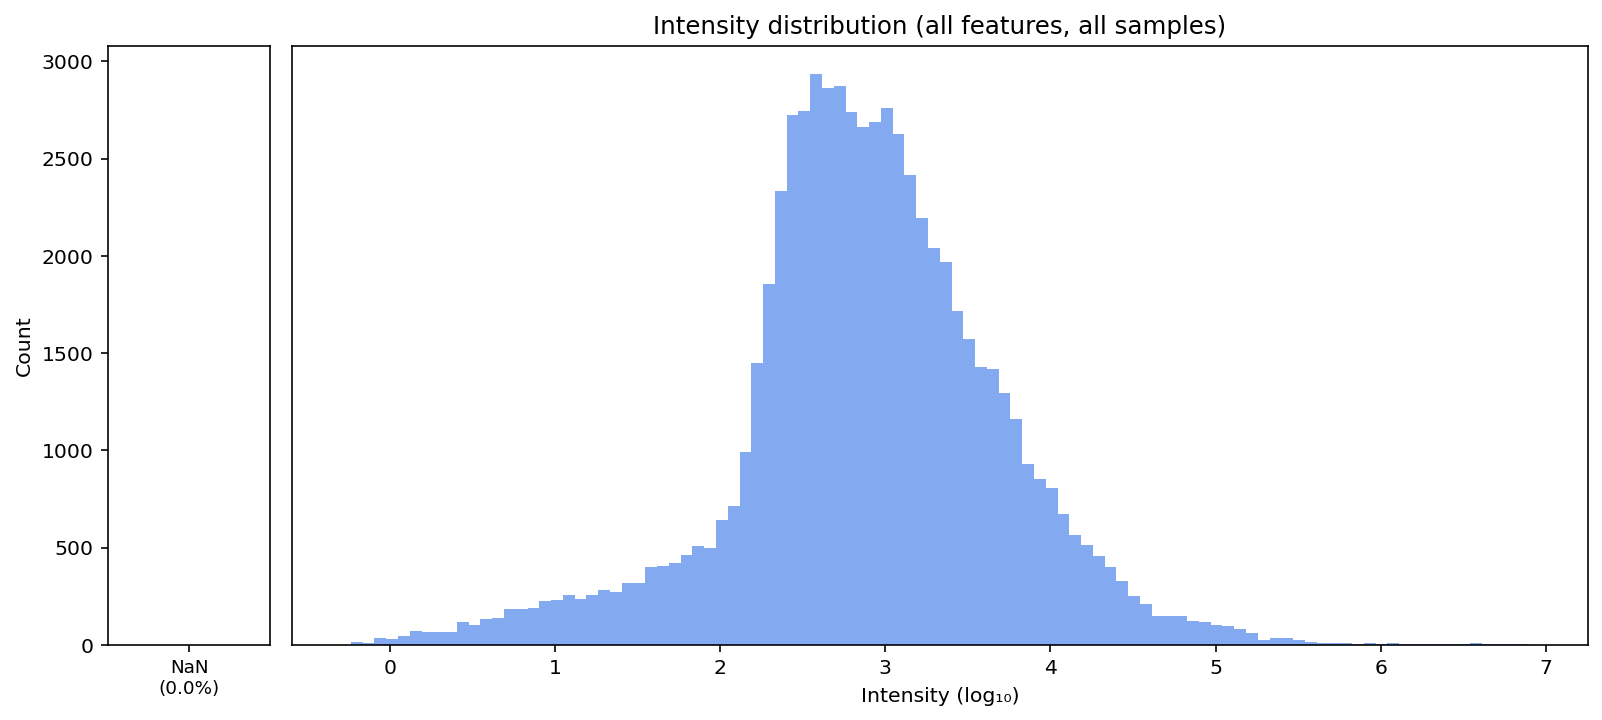

In [380]:
# Total missing count and percentage
print(
    f"Total count of missing cells: {data_imputed.isnull().sum().sum()}"
)  # total missing cells
print(
    f"Overall percentage of missingness: {data_imputed.isnull().mean().mean() * 100}\n"
)  # overall % missing

print("SUMMARY of imputation changes:")
missingness_summary(data, data_imputed)
plot_intensity_distribution(data_imputed)

Mention here possibility of imputation with zeros.

### Drift correction

In [381]:
from acore import drift_correction as dc

In [382]:
def plot_loess_example_curve(
    df: pd.DataFrame,
    feature_idx: int,
    samples: list,
    qcs: list,
    sample_order: pd.DataFrame,
    show_corrected: bool = True,
    alpha: float = None,  # fixed smoothing span; if None, selected by LOOCV
):
    """
    Plot the raw intensities, LOESS drift curve, and optionally the corrected
    intensities for a single feature according to the loess drift correction function.
    Useful for inspecting drift behaviour before running full drift correction.

    The drift curve is estimated with the same method used by
    ldc.run_drift_correction: LOESS is fit to the QC points and then
    interpolated across all injection positions via a cubic spline
    (qc_rlsc_loess).

    Parameters
    ----------
    df : pd.DataFrame
        Feature matrix with samples as rows and features as columns.
        Metadata columns should have been removed already.
    feature_idx : int
        Column index of the feature to plot.
    samples : list of str
        Row index labels of the biological samples.
    qcs : list of str
        Row index labels of the pooled QC samples.
    sample_order : pd.DataFrame
        Injection-order table with columns `File Name` and `Sample ID`
        (integer run order).
    show_corrected : bool, optional
        If True (default), overlays drift-corrected sample intensities as
        diamond markers.
    alpha : float, optional
        LOESS smoothing span (0 < α ≤ 1). If None (default), the optimal span
        is selected automatically by leave-one-out cross-validation over
        α ∈ [0.40, 1.00]. The selected value is shown in the legend.
    """

    all_rows = samples + qcs
    feature_col = df.iloc[:, feature_idx]

    order_dict = sample_order.set_index("File Name")["Sample ID"].to_dict()
    x_all = np.array([order_dict.get(r, np.nan) for r in all_rows])
    y_all = feature_col.loc[all_rows].astype(float).values

    n_s = len(samples)
    x_sample, y_sample = x_all[:n_s], y_all[:n_s]
    x_qc_arr, y_qc_arr = x_all[n_s:], y_all[n_s:]

    valid_sample = ~np.isnan(x_sample) & ~np.isnan(y_sample)
    valid_qc = ~np.isnan(x_qc_arr) & ~np.isnan(y_qc_arr)
    x_s_v, y_s_v = x_sample[valid_sample], y_sample[valid_sample]
    x_qc_v, y_qc_v = x_qc_arr[valid_qc], y_qc_arr[valid_qc]

    feature_name = df.columns[feature_idx]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.scatter(x_s_v, y_s_v, label="Samples", color="steelblue", alpha=0.7, zorder=3)
    ax.scatter(
        x_qc_v, y_qc_v, label="QC", color="firebrick", edgecolor="k", s=60, zorder=4
    )

    if len(x_qc_v) >= 4:
        if alpha is not None:
            # Pass a single-element candidate list to skip LOOCV and use the given alpha
            # directly
            drift_curve, best_alpha = dc.qc_rlsc_loess(
                x_qc_v, y_qc_v, x_all, always_use_default=True, default=alpha
            )
        else:
            drift_curve, best_alpha = dc.qc_rlsc_loess(x_qc_v, y_qc_v, x_all)

        valid_curve = ~np.isnan(x_all) & ~np.isnan(drift_curve)
        sort_idx = np.argsort(x_all[valid_curve])
        ax.plot(
            x_all[valid_curve][sort_idx],
            drift_curve[valid_curve][sort_idx],
            label=f"LOESS drift curve (α={best_alpha:.2f})",
            color="black",
            lw=2,
            zorder=5,
        )

        if show_corrected:
            median_qc = np.median(y_qc_v)
            drift_at_samples = drift_curve[:n_s][valid_sample]
            corrected = (y_s_v / drift_at_samples) * median_qc
            ax.scatter(
                x_s_v,
                corrected,
                label="Corrected samples",
                color="lightsteelblue",
                marker="D",
                s=40,
                alpha=0.9,
                zorder=3,
            )
    else:
        print(f"Not enough valid QC points for LOESS ({len(x_qc_v)} found, need ≥4).")

    ax.set_xlabel("Injection Order")
    ax.set_ylabel("Intensity")
    ax.set_title(f"Drift correction example ({feature_name})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def pca_for_cpca_drift(
    df: pd.DataFrame,
    samples,  # list of row index labels, OR dict {group_name: [row index labels]}
    qcs: list,
    log_transform: bool = True,
    title: str = "PCA",
):
    """
    PCA of samples and QC samples.

    Parameters
    ----------
    df      : feature matrix with samples as rows and features as columns.
              Metadata columns should have been removed already.
    samples : list of row index labels of the biological samples (all one group),
              or dict {group_name: [row index labels]} for multiple groups
    qcs     : list of row index labels of the pooled QC samples
    log_transform : apply log1p before scaling
    title   : plot title
    """
    # Normalise samples to a dict
    if isinstance(samples, list):
        sample_groups = {"Samples": samples}
    else:
        sample_groups = samples

    # Build ordered row + label arrays
    all_rows, labels = [], []
    for group, rows in sample_groups.items():
        for r in rows:
            if r in df.index:
                all_rows.append(r)
                labels.append(group)
    for r in qcs:
        if r in df.index:
            all_rows.append(r)
            labels.append("QC")

    # Coerce to numeric, drop features (columns) with any NaN
    X = df.loc[all_rows].apply(pd.to_numeric, errors="coerce").dropna(axis=1)

    if log_transform:
        X = np.log1p(X.clip(lower=0))

    X_scaled = StandardScaler().fit_transform(X.values.astype(float))

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100

    palette = plt.cm.tab10.colors
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(sample_groups)}
    color_map["QC"] = "black"

    fig, ax = plt.subplots(figsize=(8, 6))
    for group in list(sample_groups) + ["QC"]:
        mask = [_label == group for _label in labels]
        pts = coords[mask]
        is_qc = group == "QC"
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            label=group,
            color=color_map[group],
            marker="D" if is_qc else "o",
            s=70 if is_qc else 50,
            edgecolors="k" if is_qc else "none",
            alpha=0.9 if is_qc else 0.75,
            zorder=5 if is_qc else 3,
        )

    ax.set_xlabel(f"PC1 ({pc1_var:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_var:.1f}%)")
    ax.set_title(title)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axvline(0, color="grey", lw=0.5, ls="--")
    ax.legend(framealpha=0.8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

Loess smoothing drift correction

In [383]:
sample_order = pd.read_csv("../../dataset_metaboigniter_output/sample_metadata_metaboigniter.csv")
sample_order

,File Name,phenotype,sample_name,age,Sample ID
0,MS_QC_POOL_1_POS.mzML,QC,POOL1,NaN,1
1,MS_A_POS.mzML,CVD,A,53.000,2
2,MS_B_POS.mzML,CTR,B,30.000,3
3,MS_QC_POOL_2_POS.mzML,QC,POOL2,NaN,4
4,MS_C_POS.mzML,CTR,C,66.000,5
5,MS_D_POS.mzML,CVD,D,36.000,6
6,MS_QC_POOL_3_POS.mzML,QC,POOL3,NaN,7
7,MS_E_POS.mzML,CTR,E,66.000,8
8,MS_F_POS.mzML,CVD,F,44.000,9
9,MS_QC_POOL_4_POS.mzML,QC,POOL4,NaN,10


In [410]:
data_corrected_loess, correction_info = dc.run_loess_drift_correction(
    data = data_imputed,
    qc_rows = qcs,
    sample_rows = samples,
    sample_order = sample_order
)

In [411]:
data_corrected_loess

,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,FT0014,FT0015,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
MS_QC_POOL_1_POS.mzML,425.947,708.801,"16,784.276","3,253.079","18,595.628","61,367.035",175.779,404.491,740.330,248.157,...,164.289,"1,175.673",491.111,152.567,226.534,216.000,442.117,829.623,234.880,185.757
MS_A_POS.mzML,682.753,877.604,"24,181.355","4,466.900","36,364.199","49,386.711",138.353,430.071,332.532,359.433,...,199.460,"1,014.805",611.612,194.186,415.351,335.867,421.769,780.479,273.094,214.908
MS_B_POS.mzML,401.873,460.051,"19,373.721","3,471.530","57,067.989","64,122.249",397.660,362.442,743.789,36.733,...,65.123,"1,078.102",474.553,112.052,306.153,272.721,482.125,676.809,231.310,227.844
MS_QC_POOL_2_POS.mzML,466.685,698.858,"17,444.570","3,335.313","35,186.326","62,965.665",134.595,424.143,517.411,240.528,...,236.017,"1,199.520",514.135,187.068,301.605,189.242,423.266,840.778,242.454,215.066
MS_C_POS.mzML,303.869,787.653,"22,348.870","4,352.887","69,651.662","16,000.220",294.708,498.253,430.401,67.553,...,240.727,920.284,331.985,115.026,372.139,382.192,526.277,533.849,281.299,281.738
MS_D_POS.mzML,614.017,653.411,"22,516.471","4,299.707","25,893.346","38,859.223",237.237,415.841,211.342,491.226,...,334.782,"1,144.499",602.558,205.319,350.538,363.157,690.599,767.452,297.165,264.398
MS_QC_POOL_3_POS.mzML,427.312,705.085,"16,789.469","3,282.841","13,084.984","66,460.436",183.320,377.157,757.393,230.481,...,151.215,"1,156.068",500.644,159.265,222.381,174.990,447.338,830.374,231.137,153.527
MS_E_POS.mzML,560.166,"1,057.001","23,352.363","4,597.728","14,712.108","120,207.390",287.346,512.966,565.662,508.891,...,152.440,"1,114.668",514.975,133.954,286.899,338.673,338.578,660.784,210.829,229.758
MS_F_POS.mzML,577.430,533.707,"22,316.950","4,272.840","11,542.354","24,711.289",191.641,269.519,207.669,3.111,...,258.137,203.909,432.469,212.761,52.755,80.643,543.071,20.909,162.598,155.907
MS_QC_POOL_4_POS.mzML,443.126,706.222,"17,062.031","3,275.033","27,651.648","58,159.998",156.990,423.060,653.047,252.010,...,202.684,"1,193.726",497.706,164.753,263.416,220.592,432.045,834.123,239.599,209.563


In [415]:
correction_info["FT0011"]

{'alpha': np.float64(0.9999999999999999),
 'drift_curve': [159.21350187869893,
  157.64504126180697,
  159.69545679154203,
  174.63302450602143,
  168.00340120653067,
  157.7549017604129,
  183.08790447726392,
  163.0679176209761,
  157.1151355697731,
  161.6894004626334],
 'y_qc': [195.522942146014,
  133.34248951049,
  174.984377622378,
  154.214160839162],
 'x_qc': [1, 4, 7, 10],
 'rsd_qc': np.float64(14.088777931404753),
 'median': np.float64(164.59926923077),
 'y_all': array([185.37013636, 275.20618531, 285.92817483, 146.78686645,
        405.88386713, 227.37231818, 195.52294215, 133.34248951,
        174.98437762, 154.21416084]),
 'new_values': array([191.64071277, 287.34641209, 294.70825015, 138.35304645,
        397.65973452, 237.23711275, 175.77858836, 134.59469313,
        183.31970742, 156.98950028]),
 'status': 'corrected'}

In [ ]:
help(plot_loess_example_curve)

Help on function plot_loess_example_curve in module __main__:

plot_loess_example_curve(
    df: pd.DataFrame,
    feature_idx: int,
    samples: list,
    qcs: list,
    sample_order: pd.DataFrame,
    show_corrected: bool = True,
    alpha: float = None
)
    Plot the raw intensities, LOESS drift curve, and optionally the corrected
    intensities for a single feature according to the loess drift correction function.
    Useful for inspecting drift behaviour before running full drift correction.

    The drift curve is estimated with the same method used by
    ldc.run_drift_correction: LOESS is fit to the QC points and then
    interpolated across all injection positions via a cubic spline
    (qc_rlsc_loess).

    Parameters
    ----------
    df : pd.DataFrame
        Feature matrix with samples as rows and features as columns.
        Metadata columns should have been removed already.
    feature_idx : int
        Column index of the feature to plot.
    samples : list of str
   

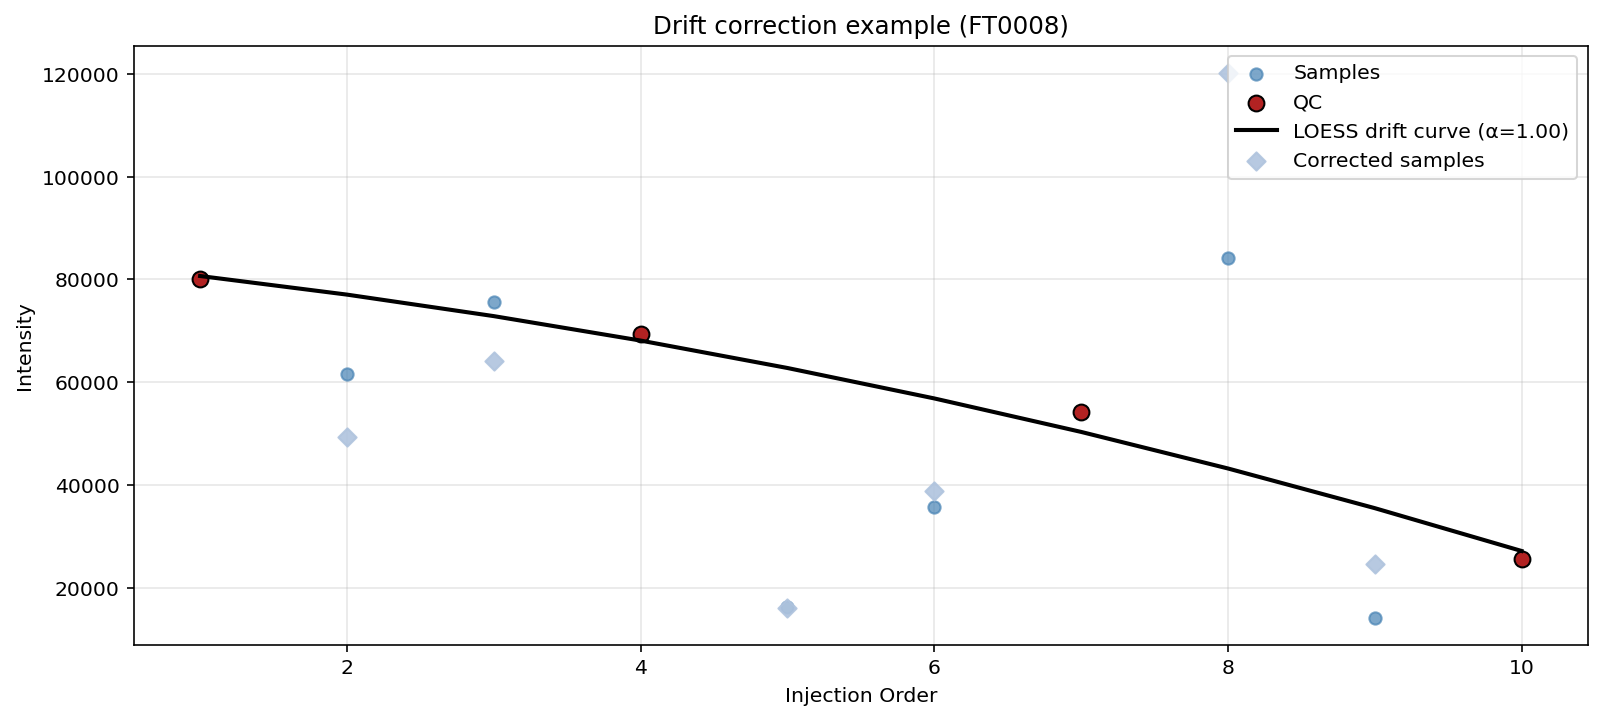

In [416]:
plot_loess_example_curve(
    df=data_imputed,
    feature_idx=5,
    samples=samples,
    qcs=qcs,
    sample_order=sample_order,
)

CPCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

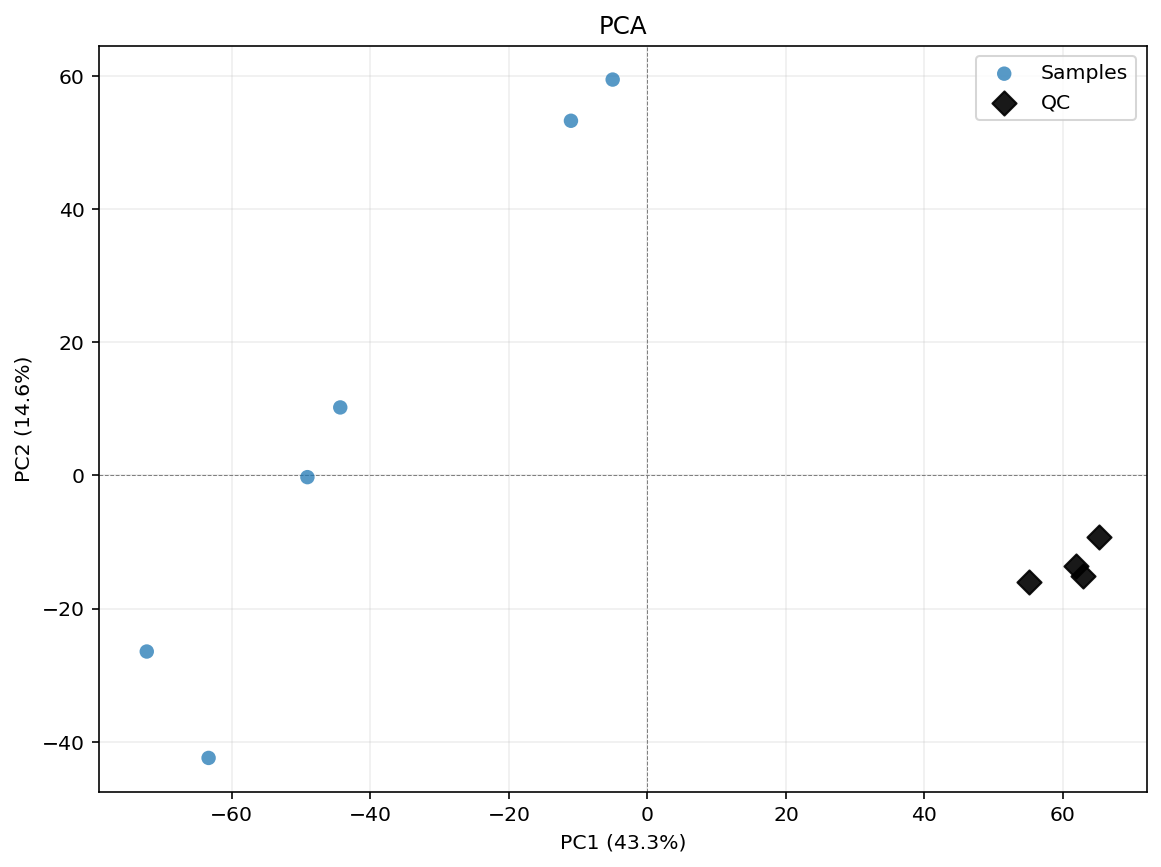

In [ ]:
pca_for_cpca_drift(
    data_imputed,
    samples = samples,  # list of col names, OR dict {group_name: [col names]}
    qcs = qcs,
    log_transform=True,
    title="PCA",
)

In [ ]:
help(dc.cpca_drift_correction)

Help on module acore.drift_correction.cpca_drift_correction in acore.drift_correction:

NAME
    acore.drift_correction.cpca_drift_correction

DESCRIPTION
    Functions for metabolomics drift correction by
    Common Principal Components Analysis (CPCA).

FUNCTIONS
    check_missingness(df: pd.DataFrame, rows_to_check: list)
        This function checks for NAs in the data frame inside some user-provided rows.

        Parameters
        ---------
        df              : samples as rows, features as columns
        rows_to_check   : list of rows that should be checked for missingness

        Returns
        --------
        Boolean: True if there is missingness, False if there is no missingness.

    cpca_centroid(
        df: pd.DataFrame,
        sample_rows,
        qc_rows: list,
        log_transform: bool = True
    )

    run_cpca_drift_correction(
        df: pd.DataFrame,
        sample_rows,
        qc_rows,
        n_comps: int = 1
    ) -> pd.DataFrame
        Corrects t

In [ ]:
data_corrected_cpca = dc.run_cpca_drift_correction(
    data_imputed,
    sample_rows = samples,
    qc_rows=qcs,
    n_comps=1
)

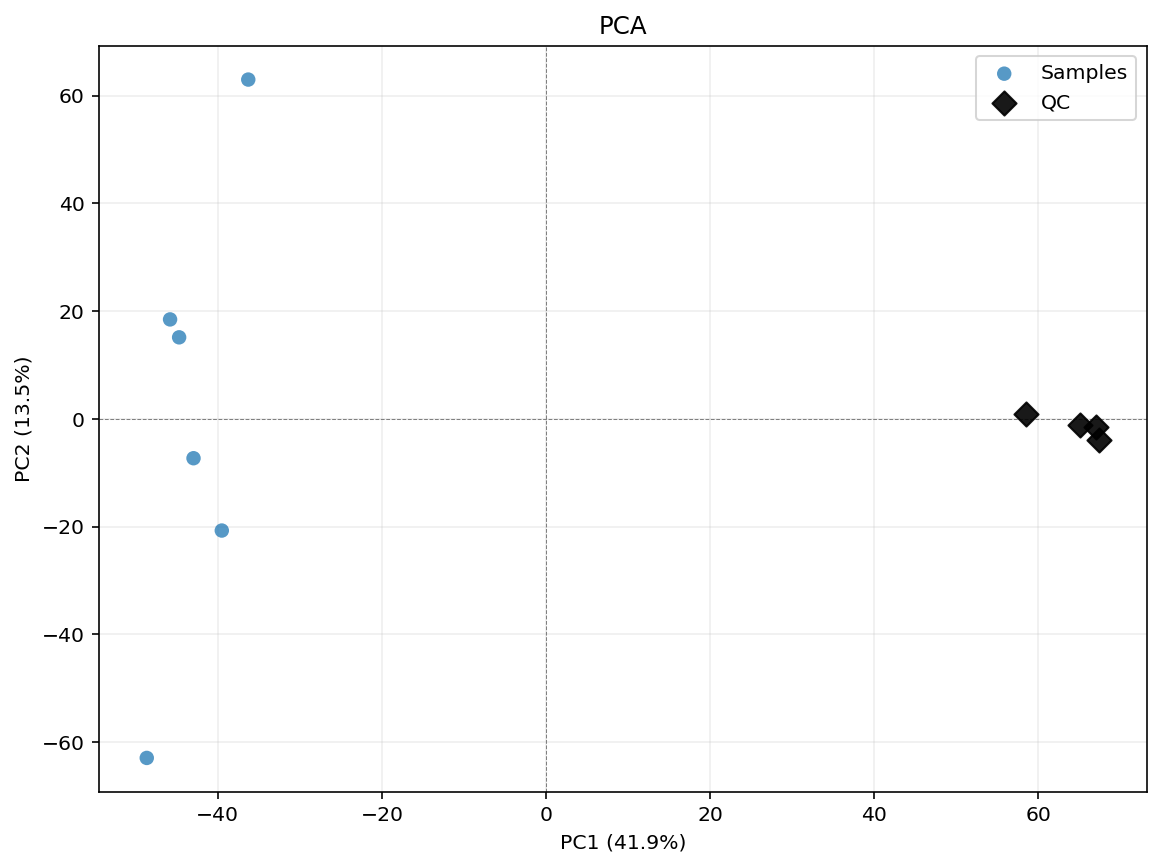

In [ ]:
pca_for_cpca_drift(
    data_corrected_cpca,
    samples = samples,  # list of col names, OR dict {group_name: [col names]}
    qcs = qcs,
    log_transform=True,
    title="PCA",
)

In [ ]:
df_corrected_2comps = dc.run_cpca_drift_correction(data_imputed, samples, qcs, n_comps=2)
df_corrected_3comps = dc.run_cpca_drift_correction(data_imputed, samples, qcs, n_comps=3)
df_corrected_4comps = dc.run_cpca_drift_correction(data_imputed, samples, qcs, n_comps=4)

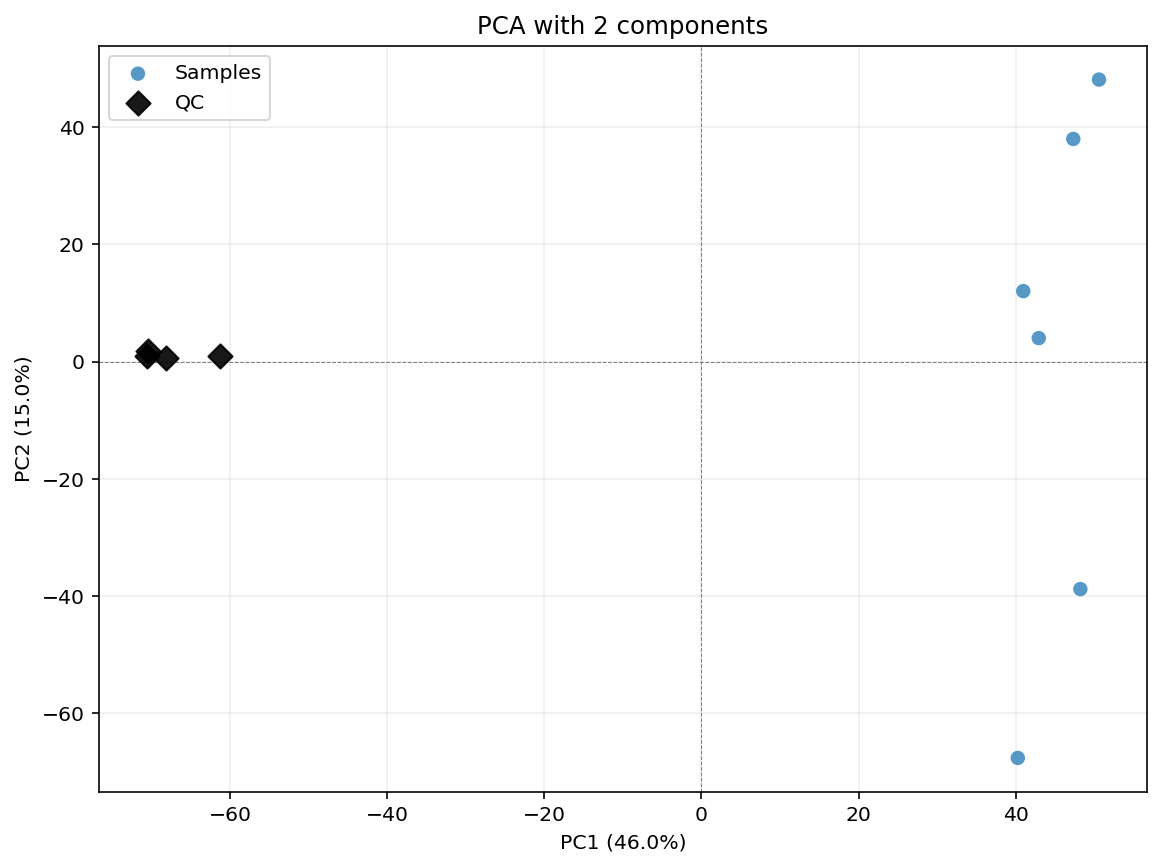

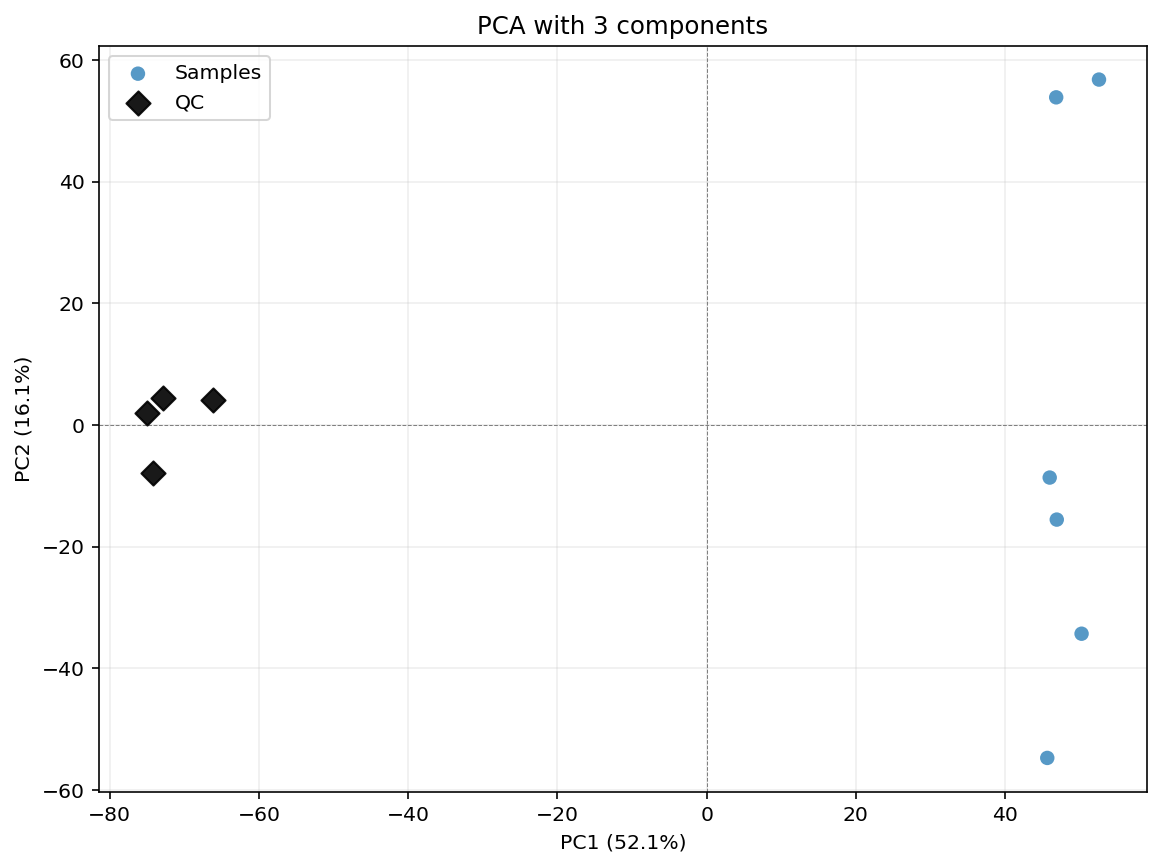

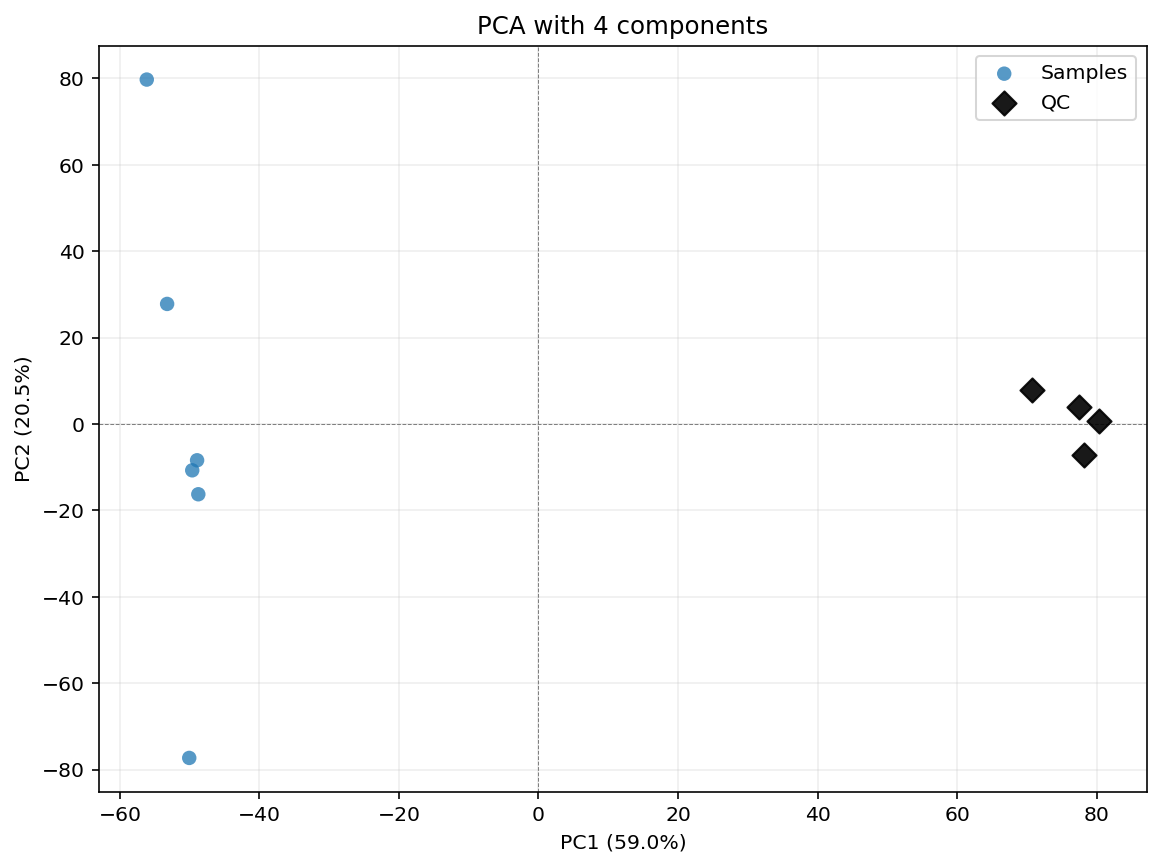

In [ ]:
pca_for_cpca_drift(
    df_corrected_2comps,
    samples,  # list of col names, OR dict {group_name: [col names]}
    qcs,
    log_transform=True,
    title="PCA with 2 components",
)

pca_for_cpca_drift(
    df_corrected_3comps,
    samples,  # list of col names, OR dict {group_name: [col names]}
    qcs,
    log_transform=True,
    title="PCA with 3 components",
)

pca_for_cpca_drift(
    df_corrected_4comps,
    samples,  # list of col names, OR dict {group_name: [col names]}
    qcs,
    log_transform=True,
    title="PCA with 4 components",
)

Continuing with the loess corrected data. Normalizing now, after imputation and correction.

### Normalization

Z-score normalization

In [ ]:
from acore import normalization

In [ ]:
data_corrected_loess

,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,FT0014,FT0015,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
MS_QC_POOL_1_POS.mzML,425.947,708.801,"16,784.276","3,253.079","18,595.628","61,367.035",175.779,404.491,740.330,248.157,...,164.289,"1,175.673",491.111,152.567,226.534,216.000,442.117,829.623,234.880,185.757
MS_A_POS.mzML,682.753,877.604,"24,181.355","4,466.900","36,364.199","49,386.711",138.353,430.071,332.532,359.433,...,199.460,"1,014.805",611.612,194.186,415.351,335.867,421.769,780.479,273.094,214.908
MS_B_POS.mzML,401.873,460.051,"19,373.721","3,471.530","57,067.989","64,122.249",397.660,362.442,743.789,36.733,...,65.123,"1,078.102",474.553,112.052,306.153,272.721,482.125,676.809,231.310,227.844
MS_QC_POOL_2_POS.mzML,466.685,698.858,"17,444.570","3,335.313","35,186.326","62,965.665",134.595,424.143,517.411,240.528,...,236.017,"1,199.520",514.135,187.068,301.605,189.242,423.266,840.778,242.454,215.066
MS_C_POS.mzML,303.869,787.653,"22,348.870","4,352.887","69,651.662","16,000.220",294.708,498.253,430.401,67.553,...,240.727,920.284,331.985,115.026,372.139,382.192,526.277,533.849,281.299,281.738
MS_D_POS.mzML,614.017,653.411,"22,516.471","4,299.707","25,893.346","38,859.223",237.237,415.841,211.342,491.226,...,334.782,"1,144.499",602.558,205.319,350.538,363.157,690.599,767.452,297.165,264.398
MS_QC_POOL_3_POS.mzML,427.312,705.085,"16,789.469","3,282.841","13,084.984","66,460.436",183.320,377.157,757.393,230.481,...,151.215,"1,156.068",500.644,159.265,222.381,174.990,447.338,830.374,231.137,153.527
MS_E_POS.mzML,560.166,"1,057.001","23,352.363","4,597.728","14,712.108","120,207.390",287.346,512.966,565.662,508.891,...,152.440,"1,114.668",514.975,133.954,286.899,338.673,338.578,660.784,210.829,229.758
MS_F_POS.mzML,577.430,533.707,"22,316.950","4,272.840","11,542.354","24,711.289",191.641,269.519,207.669,3.111,...,258.137,203.909,432.469,212.761,52.755,80.643,543.071,20.909,162.598,155.907
MS_QC_POOL_4_POS.mzML,443.126,706.222,"17,062.031","3,275.033","27,651.648","58,159.998",156.990,423.060,653.047,252.010,...,202.684,"1,193.726",497.706,164.753,263.416,220.592,432.045,834.123,239.599,209.563


In [ ]:
data_normalized = normalization.normalize_data(data_corrected_loess, "zscore")

In [ ]:
data_normalized

,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,FT0014,FT0015,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
MS_QC_POOL_1_POS.mzML,-0.065,-0.063,0.083,-0.040,0.100,0.489,-0.068,-0.066,-0.063,-0.067,...,-0.068,-0.059,-0.065,-0.068,-0.067,-0.067,-0.065,-0.062,-0.067,-0.068
MS_A_POS.mzML,-0.071,-0.069,0.225,-0.024,0.378,0.542,-0.078,-0.074,-0.076,-0.075,...,-0.077,-0.067,-0.072,-0.077,-0.075,-0.076,-0.075,-0.070,-0.076,-0.077
MS_B_POS.mzML,-0.097,-0.096,0.278,-0.036,1.023,1.162,-0.097,-0.098,-0.090,-0.104,...,-0.104,-0.084,-0.095,-0.103,-0.099,-0.099,-0.095,-0.091,-0.100,-0.100
MS_QC_POOL_2_POS.mzML,-0.062,-0.060,0.080,-0.038,0.228,0.460,-0.065,-0.063,-0.062,-0.064,...,-0.064,-0.056,-0.062,-0.065,-0.064,-0.065,-0.063,-0.059,-0.064,-0.064
MS_C_POS.mzML,-0.069,-0.064,0.186,-0.022,0.732,0.112,-0.069,-0.067,-0.068,-0.072,...,-0.070,-0.062,-0.069,-0.071,-0.068,-0.068,-0.067,-0.066,-0.069,-0.069
MS_D_POS.mzML,-0.075,-0.074,0.220,-0.025,0.265,0.440,-0.080,-0.077,-0.080,-0.076,...,-0.079,-0.068,-0.075,-0.080,-0.078,-0.078,-0.074,-0.073,-0.079,-0.079
MS_QC_POOL_3_POS.mzML,-0.065,-0.063,0.082,-0.039,0.049,0.529,-0.067,-0.066,-0.062,-0.067,...,-0.068,-0.059,-0.064,-0.067,-0.067,-0.067,-0.065,-0.061,-0.067,-0.068
MS_E_POS.mzML,-0.078,-0.070,0.288,-0.013,0.150,1.845,-0.082,-0.079,-0.078,-0.079,...,-0.084,-0.069,-0.079,-0.085,-0.082,-0.081,-0.081,-0.076,-0.083,-0.083
MS_F_POS.mzML,-0.060,-0.060,0.117,-0.030,0.029,0.136,-0.063,-0.063,-0.063,-0.065,...,-0.063,-0.063,-0.061,-0.063,-0.064,-0.064,-0.060,-0.065,-0.063,-0.064
MS_QC_POOL_4_POS.mzML,-0.064,-0.062,0.082,-0.039,0.175,0.444,-0.067,-0.064,-0.062,-0.066,...,-0.066,-0.058,-0.064,-0.067,-0.066,-0.066,-0.064,-0.061,-0.066,-0.066


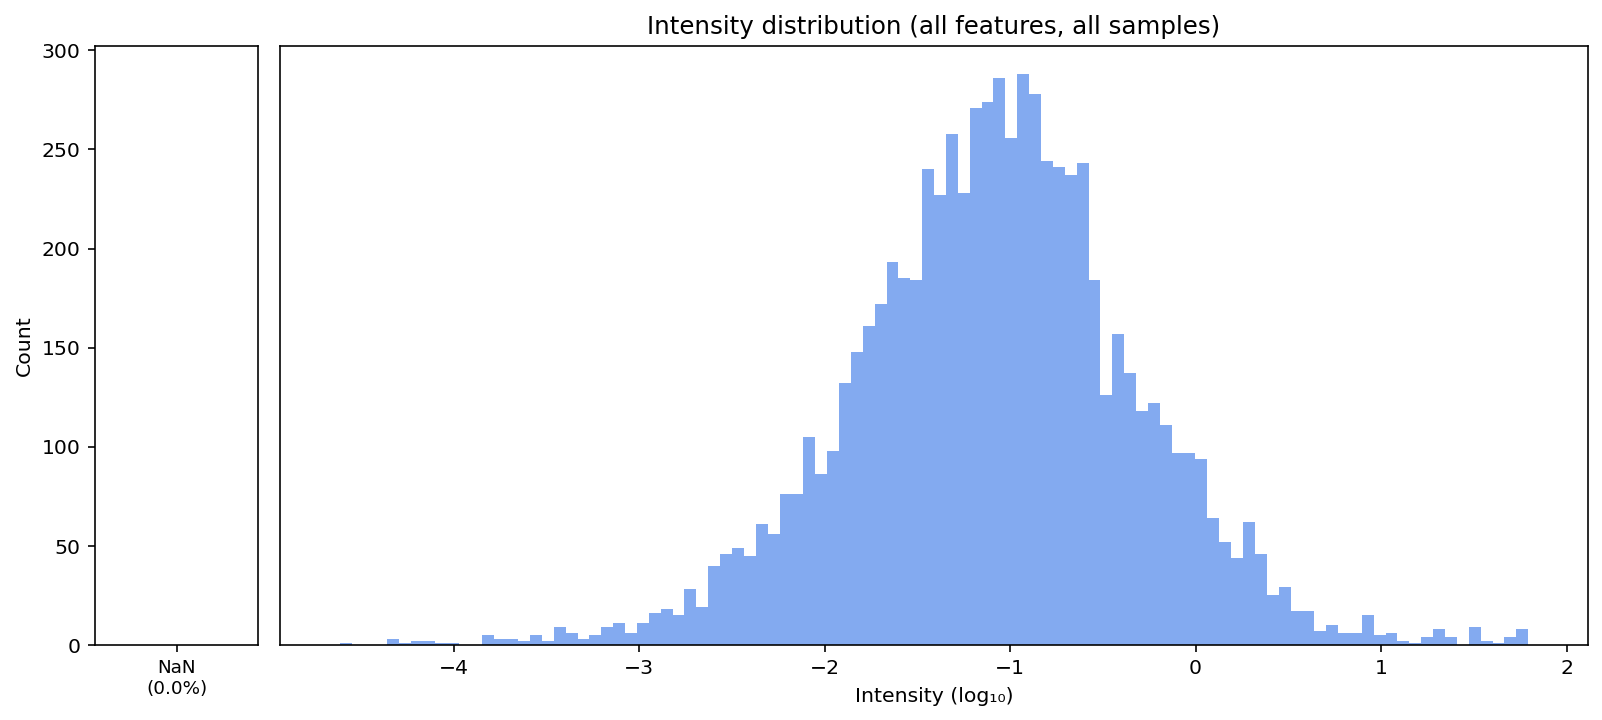

In [ ]:
plot_intensity_distribution(data_normalized)

### Statistical analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_pca(
    df: pd.DataFrame,
    groups: dict[str, list],          # e.g. {"Control": [0,1,2], "Treatment": [3,4,5]}
    scale: bool = True,
    n_components: int = 2,
    figsize: tuple = (7, 5),
    title: str = "PCA Score Plot",
    palette: list = None,
    ellipse: bool = True,             # 95% confidence ellipse per group
    label_points: bool = False,       # annotate each point with its index
):
    """
    PCA score plot for metabolomics data.

    Parameters
    ----------
    df          : samples × features DataFrame (rows = samples)
    groups      : dict mapping group name → list of row indices (int or label)
    scale       : z-score scale features before PCA (recommended)
    n_components: number of PCs to compute (≥2)
    ellipse     : draw a 95% confidence ellipse per group
    label_points: annotate each dot with its row index/label
    """

    # --- build ordered index and group label array ---
    all_idx = [i for idxs in groups.values() for i in idxs]
    group_labels = {i: grp for grp, idxs in groups.items() for i in idxs}

    X = df.loc[all_idx].copy()
    labels = [group_labels[i] for i in X.index]

    # --- scale & fit PCA ---
    if scale:
        X_vals = StandardScaler().fit_transform(X.values)
    else:
        X_vals = X.values

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_vals)
    var_exp = pca.explained_variance_ratio_ * 100

    # --- colours ---
    group_names = list(groups.keys())
    if palette is None:
        palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {g: palette[i % len(palette)] for i, g in enumerate(group_names)}

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for grp in group_names:
        mask = [l == grp for l in labels]
        pts = scores[mask]
        color = color_map[grp]

        ax.scatter(pts[:, 0], pts[:, 1], label=grp, color=color, s=80, zorder=3)

        if label_points:
            idx_list = groups[grp]
            for pt, idx in zip(pts, idx_list):
                ax.annotate(str(idx), pt, textcoords="offset points",
                            xytext=(5, 4), fontsize=8)

        if ellipse and len(pts) > 2:
            _confidence_ellipse(pts[:, 0], pts[:, 1], ax, color=color)

    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axvline(0, color="grey", lw=0.5, ls="--")
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(framealpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca, scores, var_exp


def _confidence_ellipse(x, y, ax, n_std=1.96, color="tab:blue", alpha=0.15, **kwargs):
    """Draw a covariance-based 95% confidence ellipse."""
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0), width=rx * 2, height=ry * 2,
        facecolor=color, alpha=alpha, edgecolor=color,
        linewidth=1.5, linestyle="--", **kwargs
    )
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)

    t = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

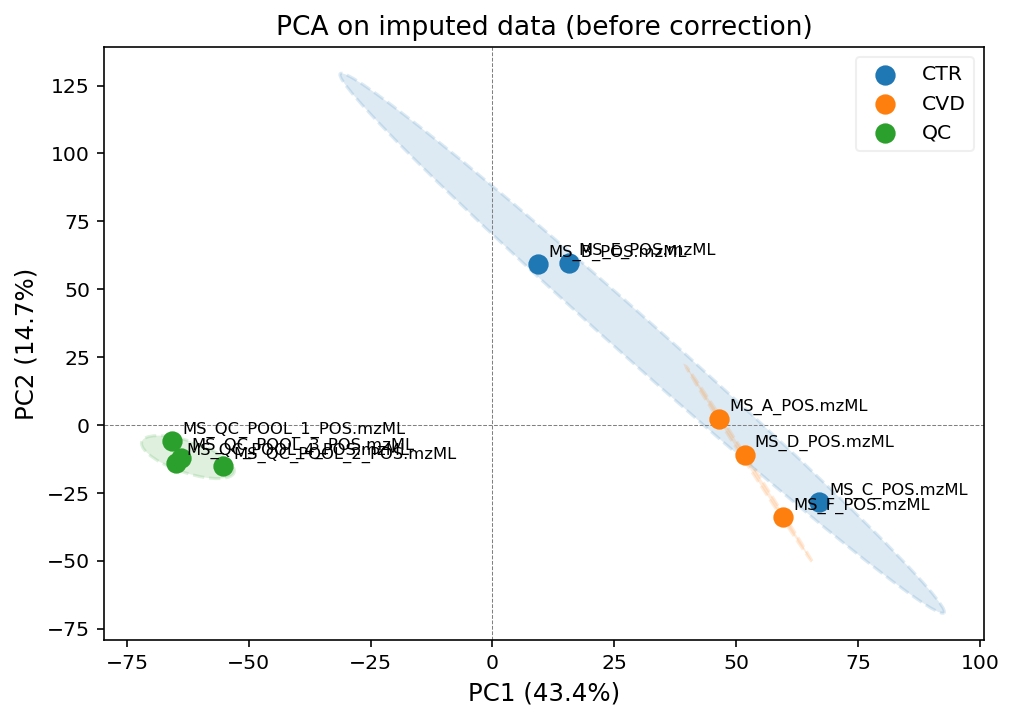

In [ ]:
groups = {
    "CTR": samples_ctr,
    "CVD": samples_cvd,
    "QC": qcs,
}
pca_model, scores, var_explained = plot_pca(data_imputed, groups, label_points=True, title="PCA on imputed data (before correction)")

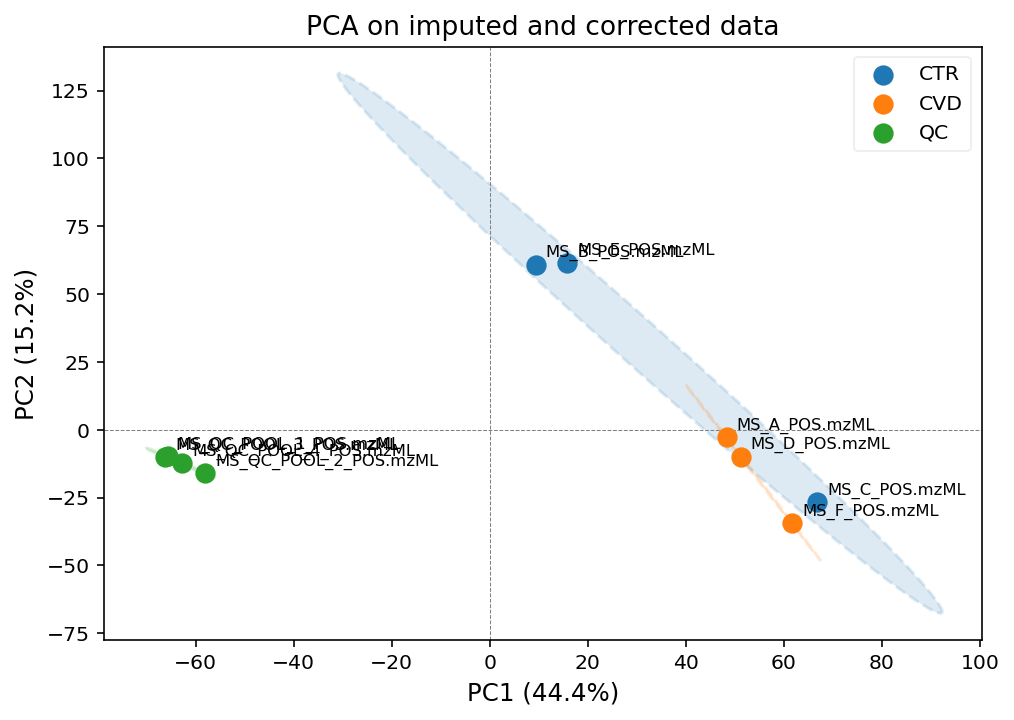

In [ ]:
pca_model, scores, var_explained = plot_pca(data_corrected_loess, groups, label_points=True, title = "PCA on imputed and corrected data")

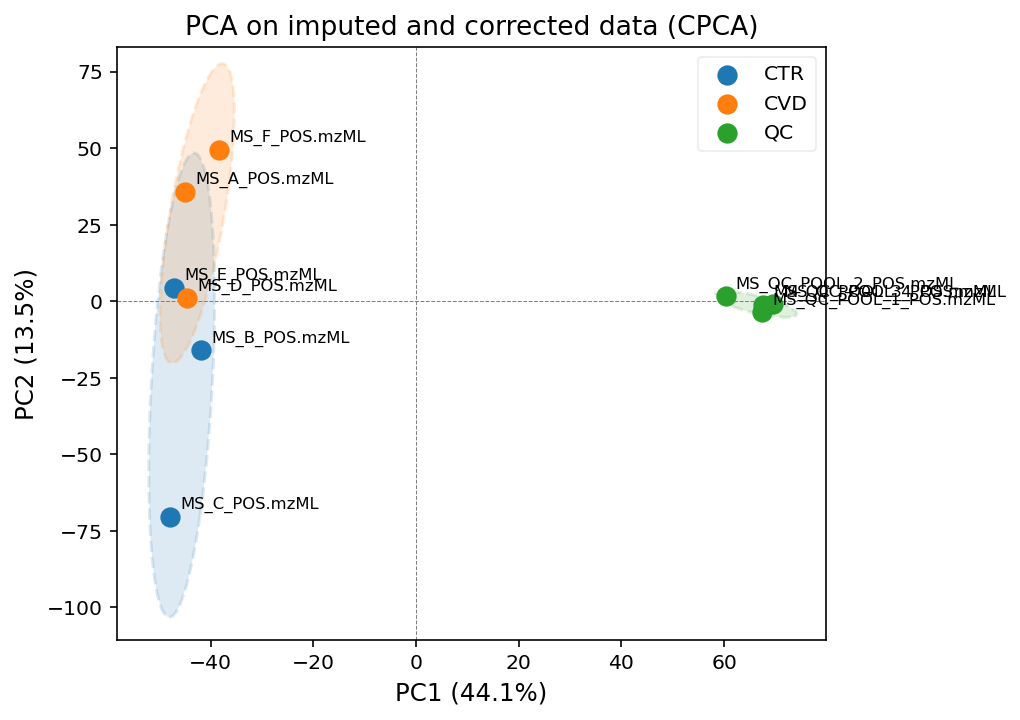

In [ ]:
pca_model, scores, var_explained = plot_pca(data_corrected_cpca, groups, label_points=True, title = "PCA on imputed and corrected data (CPCA)")

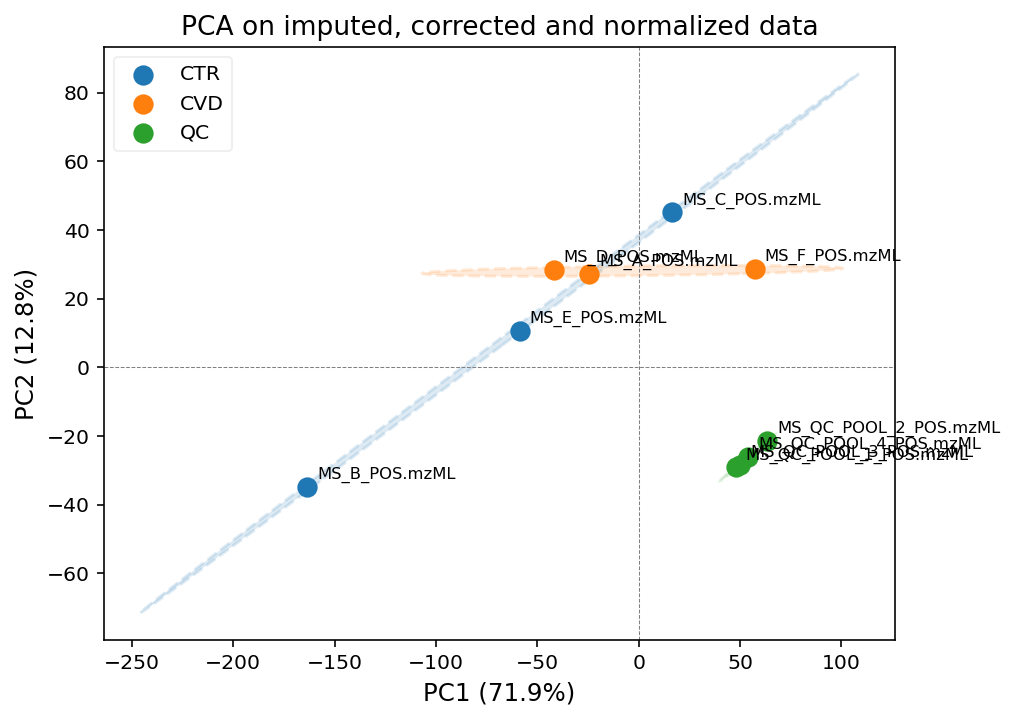

In [ ]:
pca_model, scores, var_explained = plot_pca(data_normalized, groups, label_points=True, title="PCA on imputed, corrected and normalized data")

### ANCOVA

In [ ]:
import acore.differential_regulation as ad

In [345]:
sample_order

,File Name,phenotype,sample_name,age,Sample ID
0,MS_QC_POOL_1_POS.mzML,QC,POOL1,NaN,1
1,MS_A_POS.mzML,CVD,A,53.000,2
2,MS_B_POS.mzML,CTR,B,30.000,3
3,MS_QC_POOL_2_POS.mzML,QC,POOL2,NaN,4
4,MS_C_POS.mzML,CTR,C,66.000,5
5,MS_D_POS.mzML,CVD,D,36.000,6
6,MS_QC_POOL_3_POS.mzML,QC,POOL3,NaN,7
7,MS_E_POS.mzML,CTR,E,66.000,8
8,MS_F_POS.mzML,CVD,F,44.000,9
9,MS_QC_POOL_4_POS.mzML,QC,POOL4,NaN,10


In [346]:
group = "group"
covariates = ["age"]

In [347]:
metadata = sample_order.copy()
metadata.index = metadata["File Name"]

In [348]:
data_ancova = np.log2(data_corrected_loess)
subject_col = data_ancova.index.name or "index"
data_ancova.rename_axis(subject_col, axis=0, inplace=True)

In [349]:
data_ancova

,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,FT0014,FT0015,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
index,,,,,,,,,,,,,,,,,,,,,
MS_QC_POOL_1_POS.mzML,8.735,9.469,14.035,11.668,14.183,15.905,7.458,8.660,9.532,7.955,...,7.360,10.199,8.940,7.253,7.824,7.755,8.788,9.696,7.876,7.537
MS_A_POS.mzML,9.415,9.777,14.562,12.125,15.150,15.592,7.112,8.748,8.377,8.490,...,7.640,9.987,9.256,7.601,8.698,8.392,8.720,9.608,8.093,7.748
MS_B_POS.mzML,8.651,8.846,14.242,11.761,15.800,15.969,8.635,8.502,9.539,5.199,...,6.025,10.074,8.890,6.808,8.258,8.091,8.913,9.403,7.854,7.832
MS_QC_POOL_2_POS.mzML,8.866,9.449,14.090,11.704,15.103,15.942,7.072,8.728,9.015,7.910,...,7.883,10.228,9.006,7.547,8.237,7.564,8.725,9.716,7.922,7.749
MS_C_POS.mzML,8.247,9.621,14.448,12.088,16.088,13.966,8.203,8.961,8.750,6.078,...,7.911,9.846,8.375,6.846,8.540,8.578,9.040,9.060,8.136,8.138
MS_D_POS.mzML,9.262,9.352,14.459,12.070,14.660,15.246,7.890,8.700,7.723,8.940,...,8.387,10.161,9.235,7.682,8.453,8.504,9.432,9.584,8.215,8.047
MS_QC_POOL_3_POS.mzML,8.739,9.462,14.035,11.681,13.676,16.020,7.518,8.559,9.565,7.849,...,7.240,10.175,8.968,7.315,7.797,7.451,8.805,9.698,7.853,7.262
MS_E_POS.mzML,9.130,10.046,14.511,12.167,13.845,16.875,8.167,9.003,9.144,8.991,...,7.252,10.122,9.008,7.066,8.164,8.404,8.403,9.368,7.720,7.844
MS_F_POS.mzML,9.174,9.060,14.446,12.061,13.495,14.593,7.582,8.074,7.698,1.637,...,8.012,7.672,8.756,7.733,5.721,6.333,9.085,4.386,7.345,7.285


In [350]:
group_map = {sample: label for label, samples in groups.items() for sample in samples}
data_ancova.insert(0, 'group', data_ancova.index.map(group_map))
data_ancova = data_ancova[data_ancova['group'] != 'QC']
data_ancova.insert(1, 'age', metadata["age"])


In [351]:
data_ancova

,group,age,FT0001,FT0002,FT0004,FT0005,FT0007,FT0008,FT0011,FT0012,...,FT9050,FT9051,FT9054,FT9055,FT9056,FT9061,FT9062,FT9063,FT9066,FT9067
index,,,,,,,,,,,,,,,,,,,,,
MS_A_POS.mzML,CVD,53.000,9.415,9.777,14.562,12.125,15.150,15.592,7.112,8.748,...,7.640,9.987,9.256,7.601,8.698,8.392,8.720,9.608,8.093,7.748
MS_B_POS.mzML,CTR,30.000,8.651,8.846,14.242,11.761,15.800,15.969,8.635,8.502,...,6.025,10.074,8.890,6.808,8.258,8.091,8.913,9.403,7.854,7.832
MS_C_POS.mzML,CTR,66.000,8.247,9.621,14.448,12.088,16.088,13.966,8.203,8.961,...,7.911,9.846,8.375,6.846,8.540,8.578,9.040,9.060,8.136,8.138
MS_D_POS.mzML,CVD,36.000,9.262,9.352,14.459,12.070,14.660,15.246,7.890,8.700,...,8.387,10.161,9.235,7.682,8.453,8.504,9.432,9.584,8.215,8.047
MS_E_POS.mzML,CTR,66.000,9.130,10.046,14.511,12.167,13.845,16.875,8.167,9.003,...,7.252,10.122,9.008,7.066,8.164,8.404,8.403,9.368,7.720,7.844
MS_F_POS.mzML,CVD,44.000,9.174,9.060,14.446,12.061,13.495,14.593,7.582,8.074,...,8.012,7.672,8.756,7.733,5.721,6.333,9.085,4.386,7.345,7.285


Run ANCOVA

In [386]:
ancova = (
    ad.run_ancova(
        data_ancova.astype({group: str}),  # ! target needs to be of type str
        # subject=subject_col, # not used
        drop_cols=[],
        group=group,  # needs to be a string
        covariates=covariates,
    )
    .set_index("identifier")
    .sort_values(by="padj")
)  # need to be floats?
ancova


,group1,group2,mean(group1),std(group1),mean(group2),std(group2),posthoc T-Statistics,posthoc pvalue,coef,std err,...,log2FC,FC,F-statistics,pvalue,padj,correction,rejected,-log10 pvalue,Method,posthoc padj
identifier,,,,,,,,,,,,,,,,,,,,,
FT1618,CTR,CVD,7.564,0.858,8.383,0.313,22.016,0.000,1.060,0.048,...,-0.819,0.567,484.717,0.000,0.341,FDR correction BH,False,3.688,One-way ancova,0.341
FT0732,CTR,CVD,11.979,0.486,3.252,0.485,-23.866,0.000,-8.839,0.370,...,8.727,423.836,569.604,0.000,0.341,FDR correction BH,False,3.793,One-way ancova,0.341
FT8012,CTR,CVD,5.833,0.532,7.602,0.172,32.713,0.000,1.622,0.050,...,-1.768,0.294,"1,070.158",0.000,0.341,FDR correction BH,False,4.202,One-way ancova,0.341
FT2213,CTR,CVD,9.724,0.300,10.039,0.141,22.331,0.000,0.402,0.018,...,-0.315,0.804,498.695,0.000,0.341,FDR correction BH,False,3.706,One-way ancova,0.341
FT5682,CTR,CVD,2.245,0.371,0.859,0.251,-19.127,0.000,-1.501,0.078,...,1.387,2.615,365.847,0.000,0.389,FDR correction BH,False,3.506,One-way ancova,0.389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FT8628,CTR,CVD,5.592,1.059,6.003,1.823,-0.002,0.998,-0.002,0.970,...,-0.411,0.752,0.000,0.998,0.999,FDR correction BH,False,0.001,One-way ancova,0.999
FT4658,CTR,CVD,11.076,1.356,11.282,0.460,-0.001,0.999,-0.001,0.820,...,-0.206,0.867,0.000,0.999,0.999,FDR correction BH,False,0.000,One-way ancova,0.999
FT8816,CTR,CVD,4.220,0.663,3.960,4.141,-0.000,1.000,-0.001,2.789,...,0.260,1.197,0.000,1.000,1.000,FDR correction BH,False,0.000,One-way ancova,1.000


In [387]:
ancova.sort_values(by="pvalue")

,group1,group2,mean(group1),std(group1),mean(group2),std(group2),posthoc T-Statistics,posthoc pvalue,coef,std err,...,log2FC,FC,F-statistics,pvalue,padj,correction,rejected,-log10 pvalue,Method,posthoc padj
identifier,,,,,,,,,,,,,,,,,,,,,
FT8012,CTR,CVD,5.833,0.532,7.602,0.172,32.713,0.000,1.622,0.050,...,-1.768,0.294,"1,070.158",0.000,0.341,FDR correction BH,False,4.202,One-way ancova,0.341
FT0732,CTR,CVD,11.979,0.486,3.252,0.485,-23.866,0.000,-8.839,0.370,...,8.727,423.836,569.604,0.000,0.341,FDR correction BH,False,3.793,One-way ancova,0.341
FT2213,CTR,CVD,9.724,0.300,10.039,0.141,22.331,0.000,0.402,0.018,...,-0.315,0.804,498.695,0.000,0.341,FDR correction BH,False,3.706,One-way ancova,0.341
FT1618,CTR,CVD,7.564,0.858,8.383,0.313,22.016,0.000,1.060,0.048,...,-0.819,0.567,484.717,0.000,0.341,FDR correction BH,False,3.688,One-way ancova,0.341
FT5682,CTR,CVD,2.245,0.371,0.859,0.251,-19.127,0.000,-1.501,0.078,...,1.387,2.615,365.847,0.000,0.389,FDR correction BH,False,3.506,One-way ancova,0.389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FT8353,CTR,CVD,8.388,0.627,8.380,0.302,0.002,0.999,0.001,0.476,...,0.007,1.005,0.000,0.999,0.999,FDR correction BH,False,0.001,One-way ancova,0.999
FT4658,CTR,CVD,11.076,1.356,11.282,0.460,-0.001,0.999,-0.001,0.820,...,-0.206,0.867,0.000,0.999,0.999,FDR correction BH,False,0.000,One-way ancova,0.999
FT7162,CTR,CVD,11.016,0.464,11.077,0.663,-0.001,1.000,-0.000,0.531,...,-0.061,0.959,0.000,1.000,1.000,FDR correction BH,False,0.000,One-way ancova,1.000


Inspect the results

In [354]:
ancova.iloc[:, :6]

,group1,group2,mean(group1),std(group1),mean(group2),std(group2)
identifier,,,,,,
FT1618,CTR,CVD,7.564,0.858,8.383,0.313
FT0732,CTR,CVD,11.979,0.486,3.252,0.485
FT8012,CTR,CVD,5.833,0.532,7.602,0.172
FT2213,CTR,CVD,9.724,0.300,10.039,0.141
FT5682,CTR,CVD,2.245,0.371,0.859,0.251
...,...,...,...,...,...,...
FT8628,CTR,CVD,5.592,1.059,6.003,1.823
FT4658,CTR,CVD,11.076,1.356,11.282,0.460
FT8816,CTR,CVD,4.220,0.663,3.960,4.141


Test results

In [356]:
regex_filter = "pval|padj|reject|post"
ancova.filter(regex=regex_filter)

,posthoc T-Statistics,posthoc pvalue,pvalue,padj,rejected,-log10 pvalue,posthoc padj
identifier,,,,,,,
FT1618,22.016,0.000,0.000,0.341,False,3.688,0.341
FT0732,-23.866,0.000,0.000,0.341,False,3.793,0.341
FT8012,32.713,0.000,0.000,0.341,False,4.202,0.341
FT2213,22.331,0.000,0.000,0.341,False,3.706,0.341
FT5682,-19.127,0.000,0.000,0.389,False,3.506,0.389
...,...,...,...,...,...,...,...
FT8628,-0.002,0.998,0.998,0.999,False,0.001,0.999
FT4658,-0.001,0.999,0.999,0.999,False,0.000,0.999
FT8816,-0.000,1.000,1.000,1.000,False,0.000,1.000


In [357]:
ancova.iloc[:, 6:].filter(regex=f"^(?!.*({regex_filter})).*$")

,coef,std err,Conf. Int. Low,Conf. Int. Upp.,log2FC,FC,F-statistics,correction,Method
identifier,,,,,,,,,
FT1618,1.060,0.048,0.907,1.213,-0.819,0.567,484.717,FDR correction BH,One-way ancova
FT0732,-8.839,0.370,-10.018,-7.660,8.727,423.836,569.604,FDR correction BH,One-way ancova
FT8012,1.622,0.050,1.464,1.779,-1.768,0.294,"1,070.158",FDR correction BH,One-way ancova
FT2213,0.402,0.018,0.345,0.460,-0.315,0.804,498.695,FDR correction BH,One-way ancova
FT5682,-1.501,0.078,-1.751,-1.251,1.387,2.615,365.847,FDR correction BH,One-way ancova
...,...,...,...,...,...,...,...,...,...
FT8628,-0.002,0.970,-3.088,3.084,-0.411,0.752,0.000,FDR correction BH,One-way ancova
FT4658,-0.001,0.820,-2.611,2.609,-0.206,0.867,0.000,FDR correction BH,One-way ancova
FT8816,-0.001,2.789,-8.877,8.875,0.260,1.197,0.000,FDR correction BH,One-way ancova


In [396]:
scatter_plot_adv = vuecore.plots.basic.scatter.create_scatter_plot(
    data=ancova.reset_index(),
    x="log2FC",
    y="-log10 pvalue",
    color="rejected",
    title="Simple Volcano Plot",
    subtitle="Visualizing ANCOVA results",
    labels={
        "log2FC": "Log2 Fold Change",
        "-log10 pvalue": "-log10(p-value)",
        "pvalue": "Raw P value",
        "rejected": "FDR corrected Significant",
        "identifier": "Feature Identifier",
    },
    hover_data=["identifier"],
    # currently does not work:
    # color_discrete_map={False: "#2166AC", True: "#B2182B"},  # Blue  # Red
    color_discrete_sequence=["red", "blue"],
    opacity=1,
    marker_line_width=1,
    marker_line_color="darkgray",
    width=800,
    height=600,
)
scatter_plot_adv

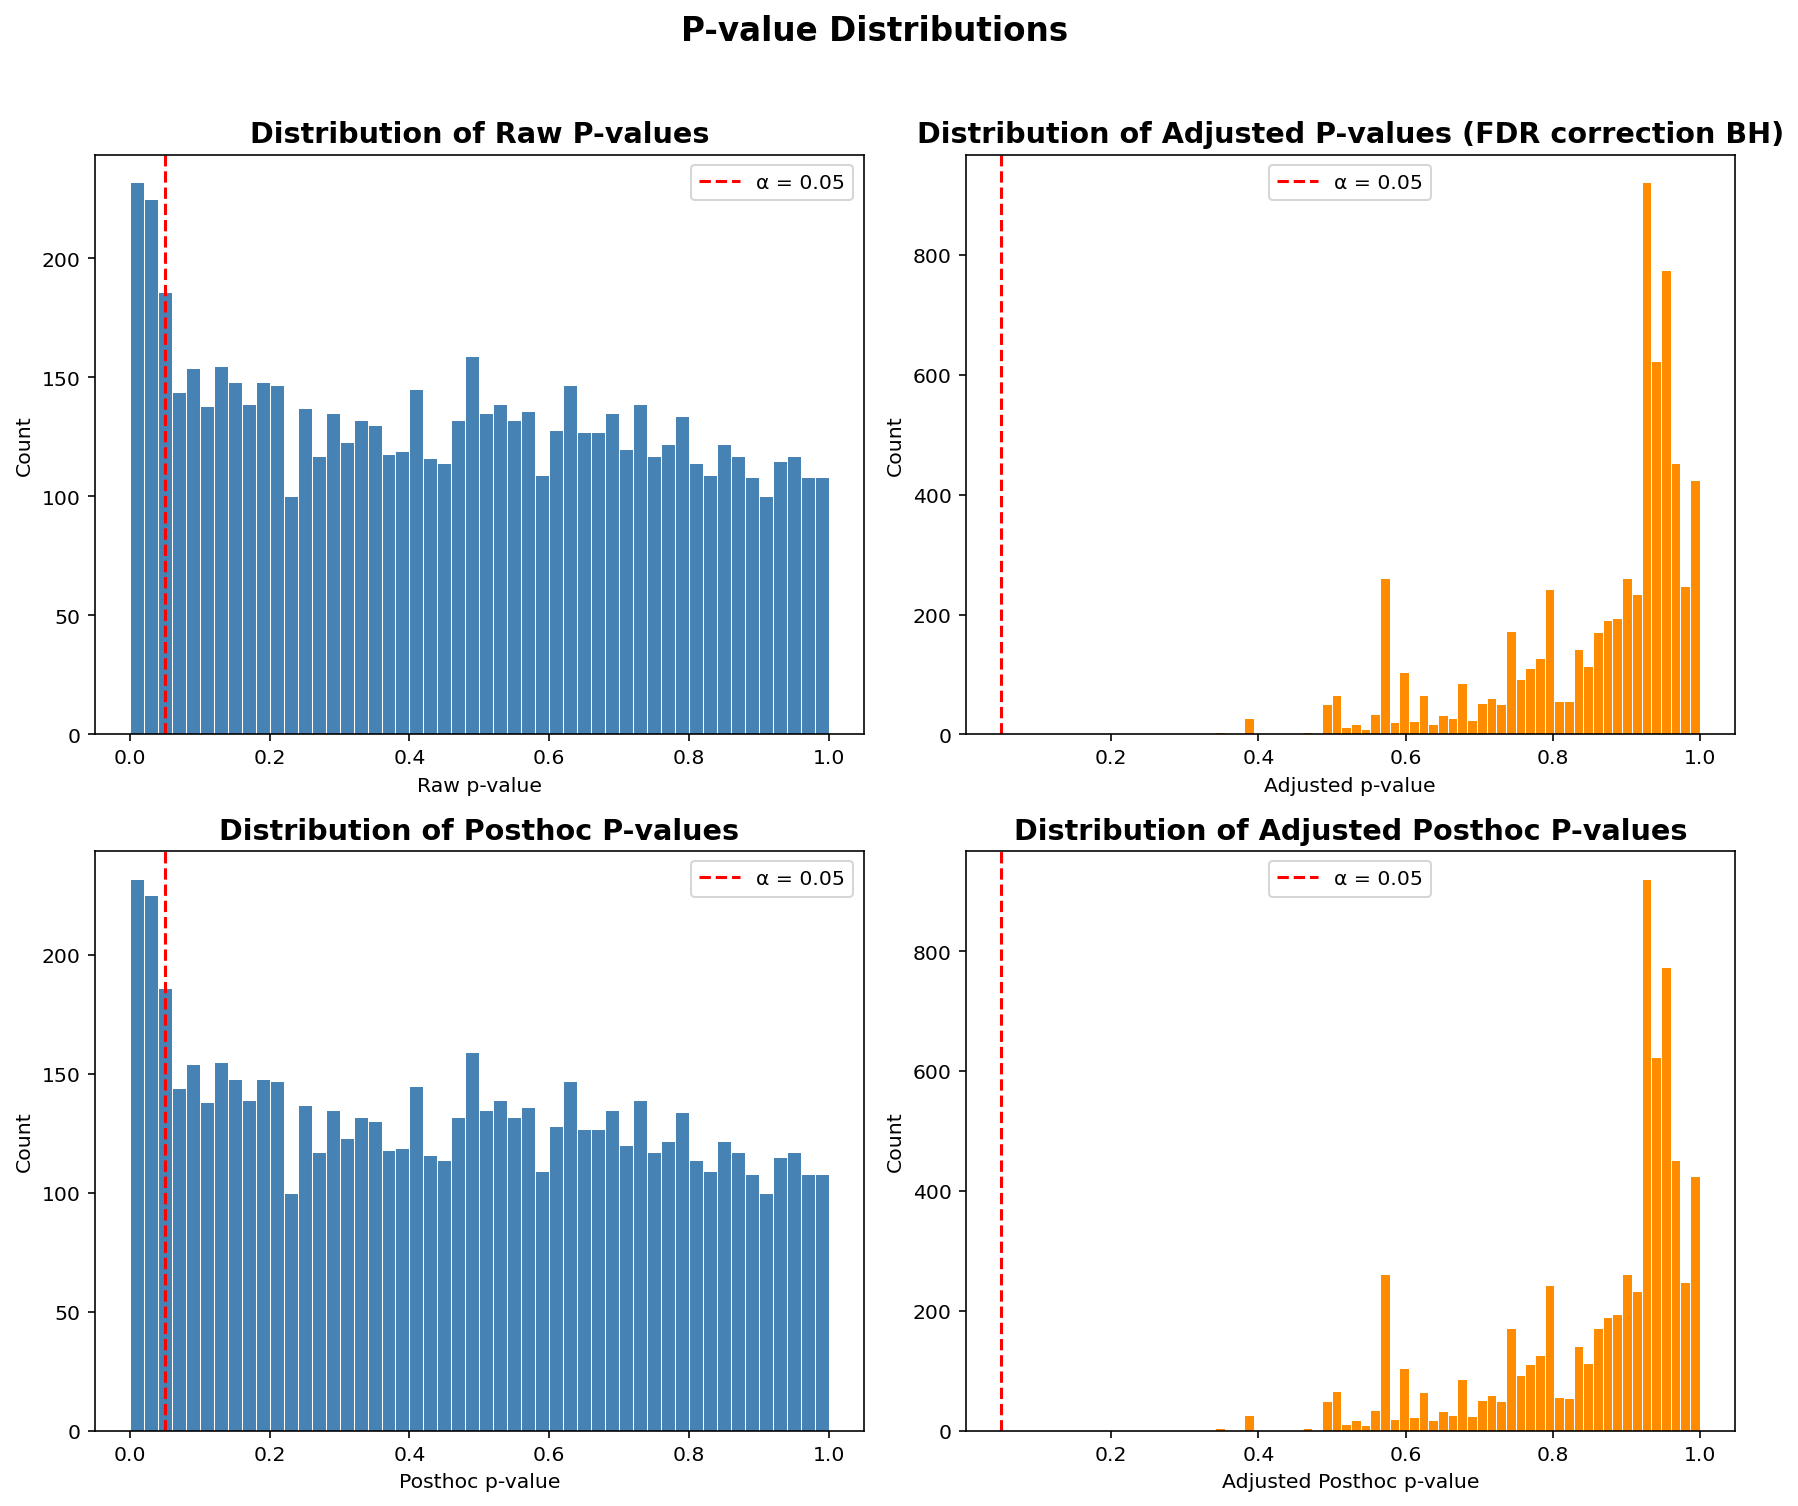

In [397]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Raw p-values
axes[0][0].hist(ancova['pvalue'].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0][0].set_title('Distribution of Raw P-values', fontsize=14, fontweight='bold')
axes[0][0].set_xlabel('Raw p-value')
axes[0][0].set_ylabel('Count')
axes[0][0].axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[0][0].legend()

# Adjusted p-values
axes[0][1].hist(ancova['padj'].dropna(), bins=50, color='darkorange', edgecolor='white', linewidth=0.5)
axes[0][1].set_title('Distribution of Adjusted P-values (FDR correction BH)', fontsize=14, fontweight='bold')
axes[0][1].set_xlabel('Adjusted p-value')
axes[0][1].set_ylabel('Count')
axes[0][1].axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[0][1].legend()

# Raw p-values
axes[1][0].hist(ancova['posthoc pvalue'].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1][0].set_title('Distribution of Posthoc P-values', fontsize=14, fontweight='bold')
axes[1][0].set_xlabel('Posthoc p-value')
axes[1][0].set_ylabel('Count')
axes[1][0].axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[1][0].legend()

# Adjusted p-values
axes[1][1].hist(ancova['posthoc padj'].dropna(), bins=50, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1][1].set_title('Distribution of Adjusted Posthoc P-values', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Adjusted Posthoc p-value')
axes[1][1].set_ylabel('Count')
axes[1][1].axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[1][1].legend()

plt.suptitle('P-value Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pvalue_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [401]:
# How many survive at different thresholds?
print("Raw p < 0.05:", (ancova['pvalue'] < 0.05).sum())
print("Raw p < 0.01:", (ancova['pvalue'] < 0.01).sum())
print("padj < 0.05: ", (ancova['padj'] < 0.05).sum())
print("padj < 0.1:  ", (ancova['padj'] < 0.1).sum())

# What are your two groups?
print(ancova[['group1', 'group2']].drop_duplicates())

Raw p < 0.05: 557
Raw p < 0.01: 131
padj < 0.05:  0
padj < 0.1:   0
           group1 group2
identifier              
FT1618        CTR    CVD


Identify hits

In [403]:
# Primary hit list for follow-up
hits = ancova[
    (ancova['pvalue'] < 0.01) & 
    (ancova['log2FC'].abs() > 1)
]
print(f"Candidate metabolites: {len(hits)}")
print(f"Upregulated in CVD: {(hits['log2FC'] > 0).sum()}")
print(f"Downregulated in CVD: {(hits['log2FC'] < 0).sum()}")

Candidate metabolites: 64
Upregulated in CVD: 32
Downregulated in CVD: 32


In [404]:
hits

,group1,group2,mean(group1),std(group1),mean(group2),std(group2),posthoc T-Statistics,posthoc pvalue,coef,std err,...,FC,F-statistics,pvalue,padj,correction,rejected,-log10 pvalue,Method,posthoc padj,expected_log2FC
identifier,,,,,,,,,,,,,,,,,,,,,
FT0732,CTR,CVD,11.979,0.486,3.252,0.485,-23.866,0.000,-8.839,0.370,...,423.836,569.604,0.000,0.341,FDR correction BH,False,3.793,One-way ancova,0.341,-1.881
FT8012,CTR,CVD,5.833,0.532,7.602,0.172,32.713,0.000,1.622,0.050,...,0.294,"1,070.158",0.000,0.341,FDR correction BH,False,4.202,One-way ancova,0.341,0.382
FT5682,CTR,CVD,2.245,0.371,0.859,0.251,-19.127,0.000,-1.501,0.078,...,2.615,365.847,0.000,0.389,FDR correction BH,False,3.506,One-way ancova,0.389,-1.387
FT6012,CTR,CVD,6.150,0.974,10.392,0.642,10.926,0.002,4.506,0.412,...,0.053,119.376,0.002,0.389,FDR correction BH,False,2.785,One-way ancova,0.389,0.757
FT5948,CTR,CVD,8.422,1.025,10.994,0.271,10.716,0.002,2.834,0.264,...,0.168,114.841,0.002,0.389,FDR correction BH,False,2.760,One-way ancova,0.389,0.384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FT1255,CTR,CVD,7.949,1.120,9.605,0.181,6.220,0.008,1.931,0.311,...,0.317,38.684,0.008,0.501,FDR correction BH,False,2.077,One-way ancova,0.501,0.273
FT2232,CTR,CVD,2.772,1.501,8.494,0.479,6.086,0.009,5.903,0.970,...,0.019,37.040,0.009,0.501,FDR correction BH,False,2.050,One-way ancova,0.501,1.615
FT2519,CTR,CVD,10.797,1.047,12.001,0.100,5.954,0.009,1.465,0.246,...,0.434,35.451,0.009,0.501,FDR correction BH,False,2.023,One-way ancova,0.501,0.152
